<a href="https://colab.research.google.com/github/jeanraposojesus-hue/Pratica-1-PROCSIN/blob/main/Pr%C3%A1tica_7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

--- Exemplo: Questão 1(a) - Passa-baixas, fc=1000Hz ---


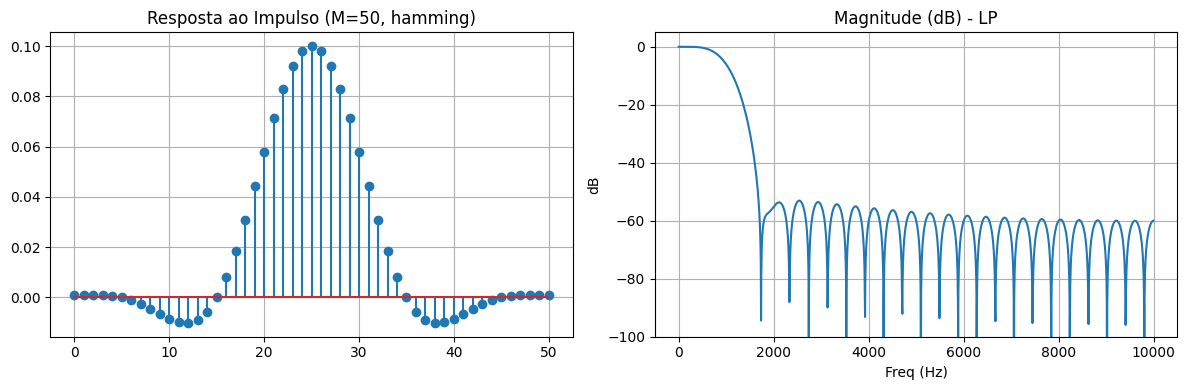

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

# 1. Implementação Manual das Janelas
def get_window(name, M):
    n = np.arange(M + 1)
    if name == 'retangular':
        return np.ones(M + 1)
    elif name == 'triangular' or name == 'bartlett':
        return 1 - np.abs(2*n - M) / M
    elif name == 'hamming':
        return 0.54 - 0.46 * np.cos(2 * np.pi * n / M)
    elif name == 'hann':
        return 0.5 * (1 - np.cos(2 * np.pi * n / M))
    elif name == 'blackman':
        return 0.42 - 0.5 * np.cos(2 * np.pi * n / M) + 0.08 * np.cos(4 * np.pi * n / M)
    else:
        return np.ones(M + 1)

# 2. Implementação das Respostas ao Impulso Ideais (Sinc)
def ideal_lp(wc, M):
    n = np.arange(M + 1)
    alpha = M / 2
    h = np.sinc(wc * (n - alpha) / np.pi) * (wc / np.pi)
    return h

# 3. Função para projetar e plotar (Didática)
def projetar_e_plotar(M, window_name, filter_type, fs=20000, **kwargs):
    wc1 = 2 * np.pi * kwargs.get('f1', 0) / fs
    wc2 = 2 * np.pi * kwargs.get('f2', 0) / fs

    # Definindo h_ideal[n]
    if filter_type == 'lp':
        h_ideal = ideal_lp(wc1, M)
    elif filter_type == 'hp':
        h_ideal = ideal_lp(np.pi, M) - ideal_lp(wc1, M)
    elif filter_type == 'bp':
        h_ideal = ideal_lp(wc2, M) - ideal_lp(wc1, M)
    elif filter_type == 'bs':
        h_ideal = ideal_lp(wc1, M) + (ideal_lp(np.pi, M) - ideal_lp(wc2, M))

    # Aplicando a Janela
    win = get_window(window_name, M)
    h = h_ideal * win

    # Resposta em Frequência
    w, h_freq = signal.freqz(h, 1, worN=2000)
    f = w * fs / (2 * np.pi)

    # Plotagem
    plt.figure(figsize=(12, 4))

    # Resposta ao Impulso
    plt.subplot(1, 2, 1)
    plt.stem(h)
    plt.title(f'Resposta ao Impulso (M={M}, {window_name})')
    plt.grid(True)

    # Resposta em Frequência (Magnitude)
    plt.subplot(1, 2, 2)
    plt.plot(f, 20 * np.log10(np.abs(h_freq)))
    plt.title(f'Magnitude (dB) - {filter_type.upper()}')
    plt.ylabel('dB')
    plt.xlabel('Freq (Hz)')
    plt.ylim([-100, 5])
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# Exemplo: Item (a) Passa-baixas, fc=1000Hz, Janela Hamming, M=50
print("--- Exemplo: Questão 1(a) - Passa-baixas, fc=1000Hz ---")
projetar_e_plotar(M=50, window_name='hamming', filter_type='lp', f1=1000)


==================== PROJETO: Passa-Baixas | M = 20 | fc = 1000Hz ====================

Janela: Retangular


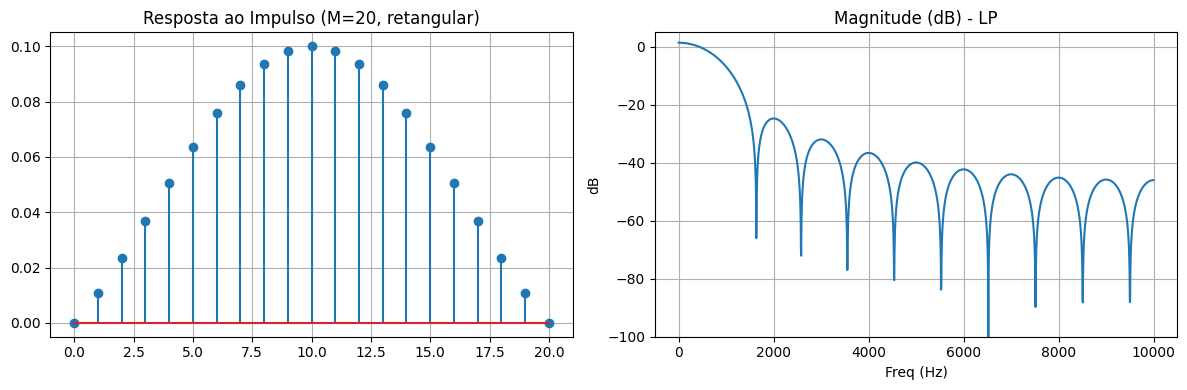

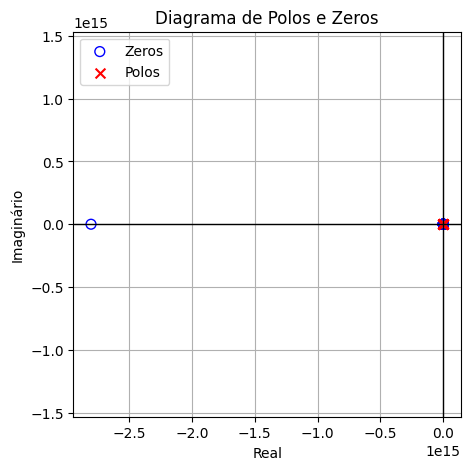


Janela: Hamming


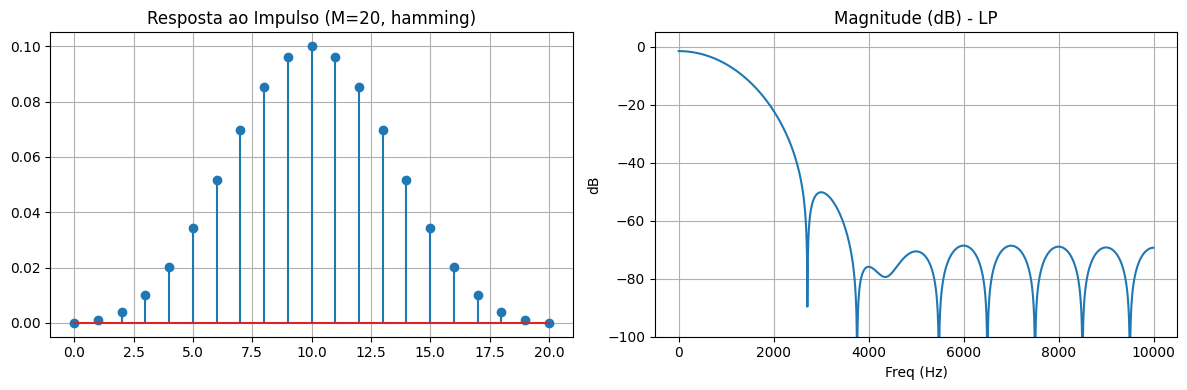

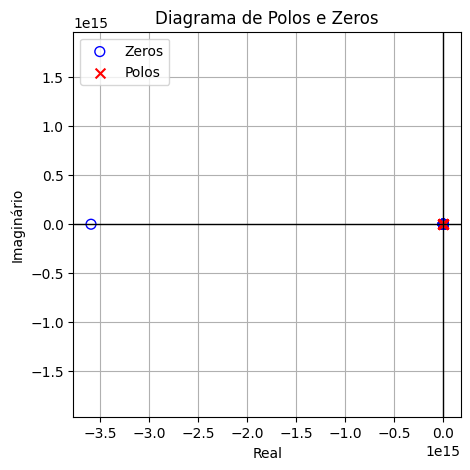


Janela: Blackman


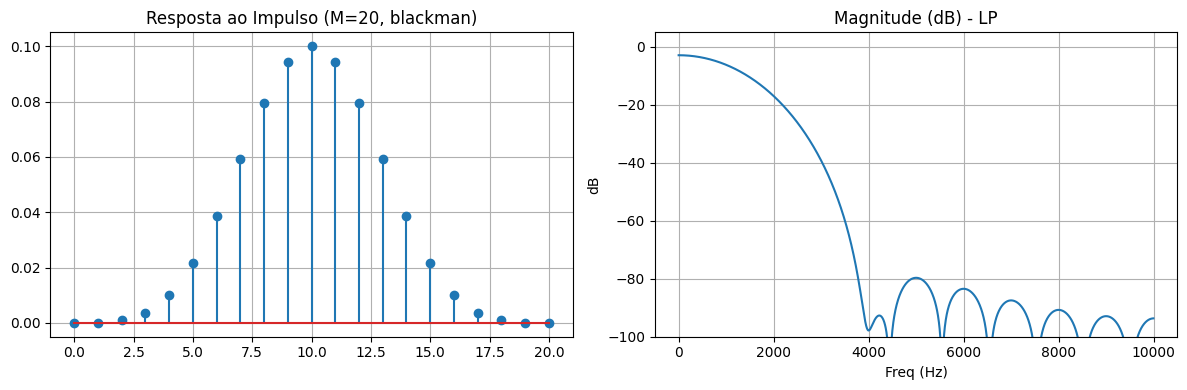

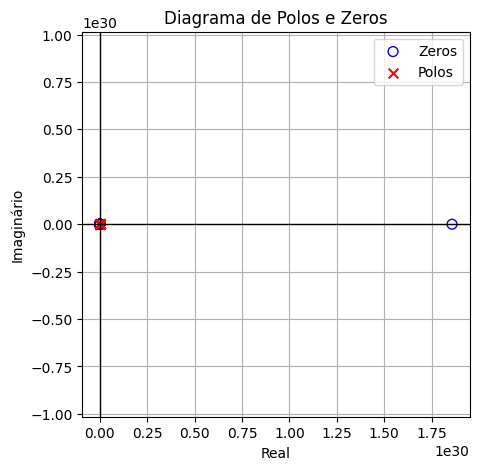


==================== PROJETO: Passa-Baixas | M = 50 | fc = 1000Hz ====================

Janela: Retangular


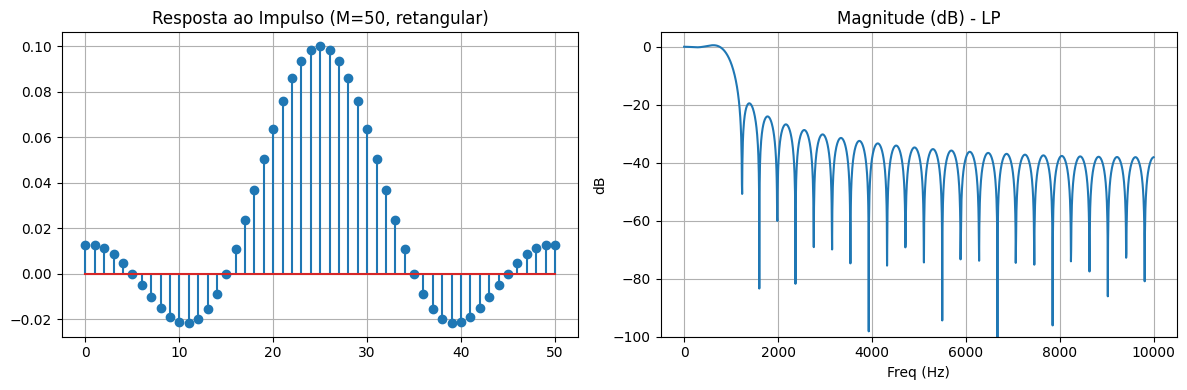

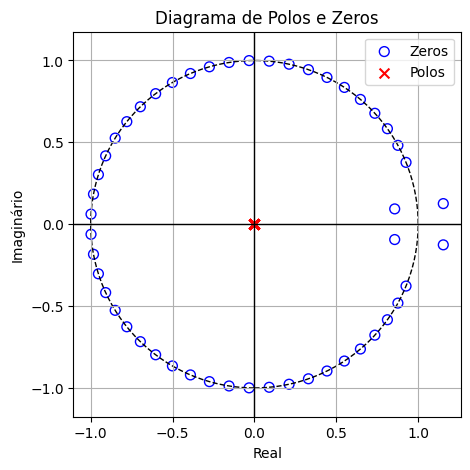


Janela: Hamming


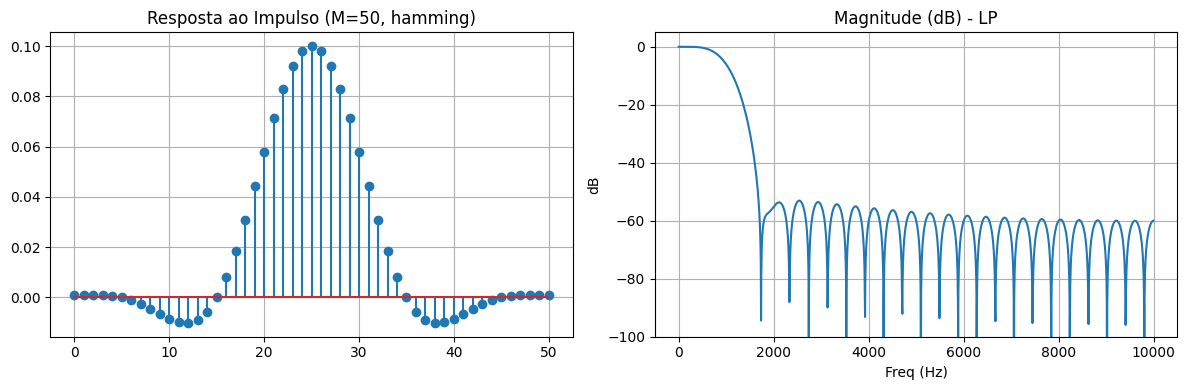

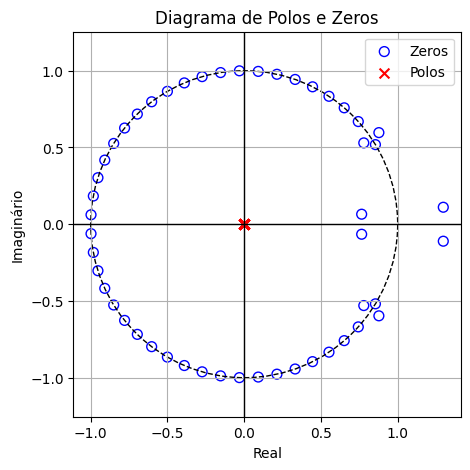


Janela: Blackman


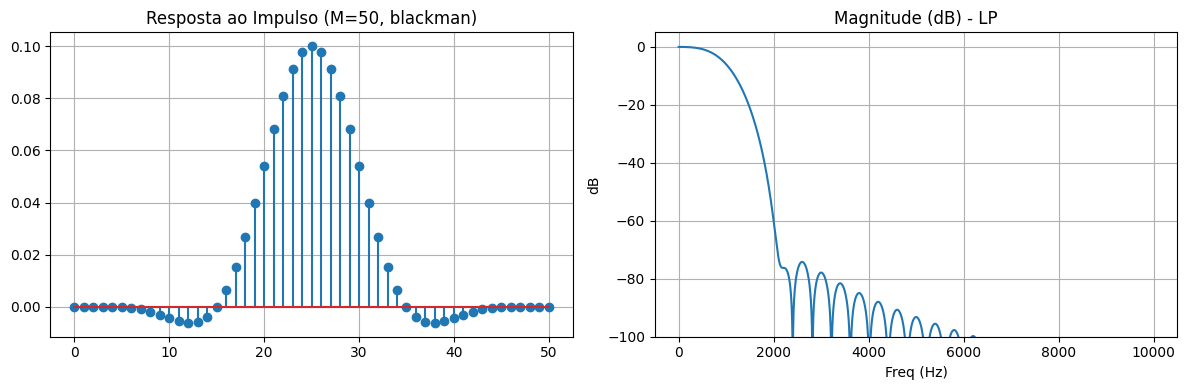

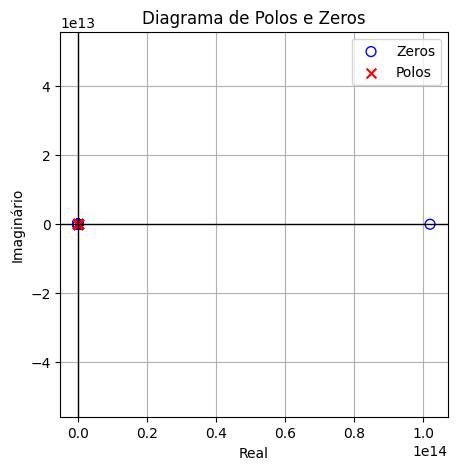

In [3]:
def plot_poles_zeros(h):
    """Gera o diagrama de polos e zeros para um filtro FIR."""
    zeros = np.roots(h)
    poles = np.zeros(len(h) - 1)

    plt.figure(figsize=(5, 5))
    plt.scatter(np.real(zeros), np.imag(zeros), s=50, marker='o', edgecolors='b', facecolors='none', label='Zeros')
    plt.scatter(np.real(poles), np.imag(poles), s=50, marker='x', color='r', label='Polos')

    # Desenha o círculo unitário
    unit_circle = plt.Circle((0,0), 1, color='black', fill=False, linestyle='--')
    plt.gca().add_artist(unit_circle)

    plt.axhline(0, color='black', lw=1)
    plt.axvline(0, color='black', lw=1)
    plt.title('Diagrama de Polos e Zeros')
    plt.xlabel('Real')
    plt.ylabel('Imaginário')
    plt.legend()
    plt.grid(True)
    plt.axis('equal')
    plt.show()

# --- Demonstração do Item 1(a) completa ---
# Passa-baixas, fc = 1000 Hz, fs = 20000 Hz
fs = 20000
fc = 1000

for m_val in [20, 50]:
    print(f"\n{'='*20} PROJETO: Passa-Baixas | M = {m_val} | fc = 1000Hz {'='*20}")
    for win_name in ['retangular', 'hamming', 'blackman']:
        print(f"\nJanela: {win_name.capitalize()}")
        # Calculando coeficientes
        wc = 2 * np.pi * fc / fs
        h_ideal = ideal_lp(wc, m_val)
        win = get_window(win_name, m_val)
        h = h_ideal * win

        # Mostrando Resposta ao Impulso e Frequência
        projetar_e_plotar(m_val, win_name, 'lp', fs=fs, f1=fc)
        # Mostrando Polos e Zeros
        plot_poles_zeros(h)


##############################
ITEM (b) - PASSA-ALTAS (2000 Hz)
##############################


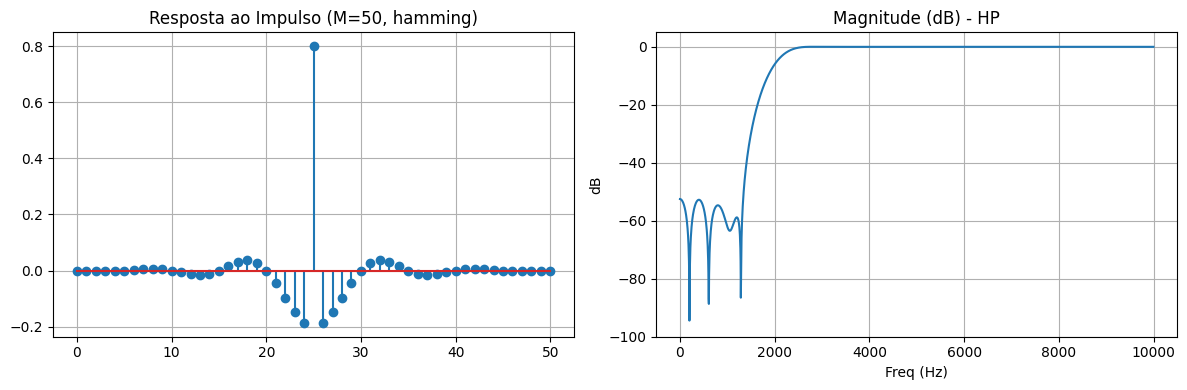


##############################
ITEM (c) - PASSA-FAIXAS (500-2000 Hz)
##############################


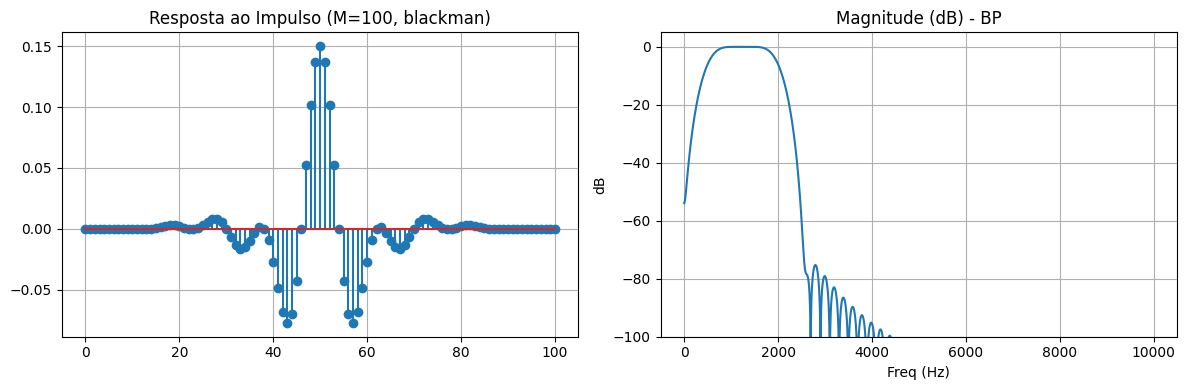


##############################
ITEM (d) - REJEITA-FAIXAS (1000-2500 Hz)
##############################


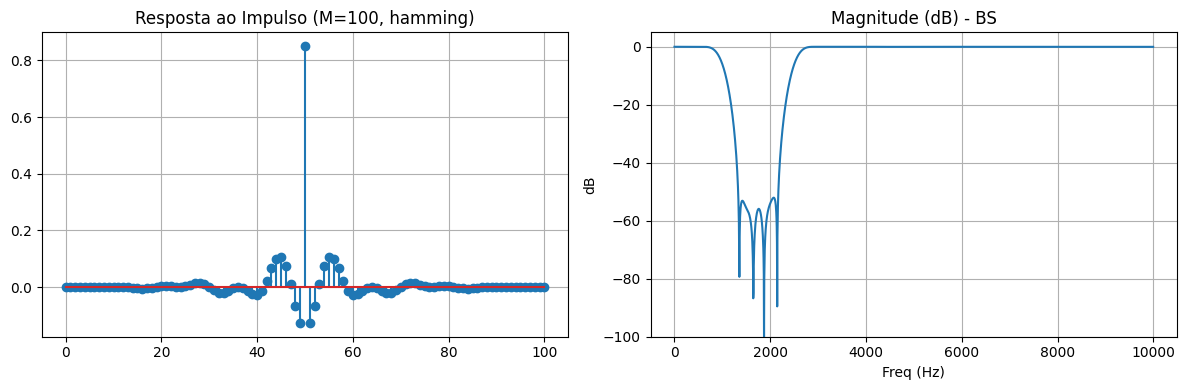

In [4]:
# Resolução dos itens (b), (c) e (d) da Questão 1

fs = 20000

# Item (b) Passa-altas com fc = 2000 Hz
print("\n" + "#"*30 + "\nITEM (b) - PASSA-ALTAS (2000 Hz)\n" + "#"*30)
projetar_e_plotar(M=50, window_name='hamming', filter_type='hp', f1=2000)

# Item (c) Passa-faixas com fc1 = 500 Hz, fc2 = 2000 Hz
print("\n" + "#"*30 + "\nITEM (c) - PASSA-FAIXAS (500-2000 Hz)\n" + "#"*30)
projetar_e_plotar(M=100, window_name='blackman', filter_type='bp', f1=500, f2=2000)

# Item (d) Rejeita-faixas com fc1 = 1000 Hz, fc2 = 2500 Hz
print("\n" + "#"*30 + "\nITEM (d) - REJEITA-FAIXAS (1000-2500 Hz)\n" + "#"*30)
projetar_e_plotar(M=100, window_name='hamming', filter_type='bs', f1=1000, f2=2500)

### Questão 2 - Derivação e Projeto

Para filtros ideais com magnitude $H_d(\omega)$, a resposta ao impulso é dada por:
$$h_d[n] = \frac{1}{2\pi} \int_{-\pi}^{\pi} H_d(\omega) e^{j\omega(n-\alpha)} d\omega$$
onde $\alpha = M/2$ garante a causalidade e fase linear.

No código abaixo, projetamos os filtros solicitados na Questão 2.


########################################
RESOLVENDO QUESTÃO 2 - ITEM (a)
########################################

Projetando: M=50, Janela=Hamming


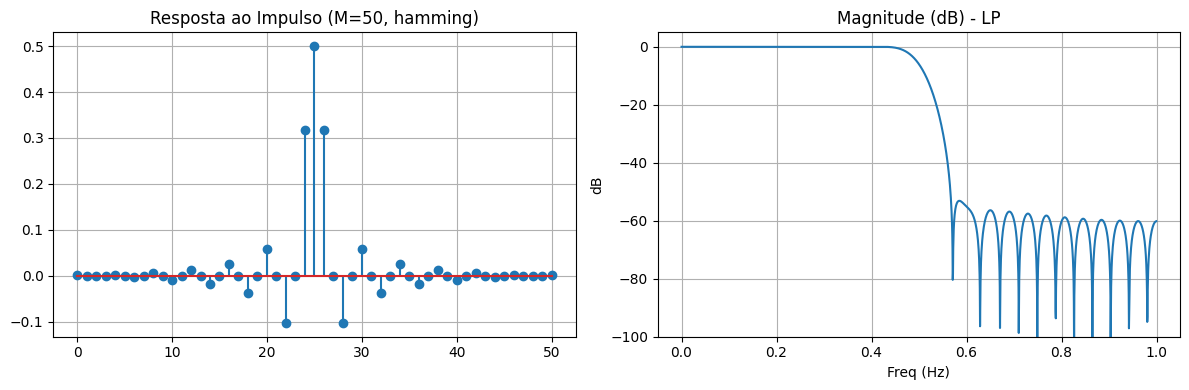

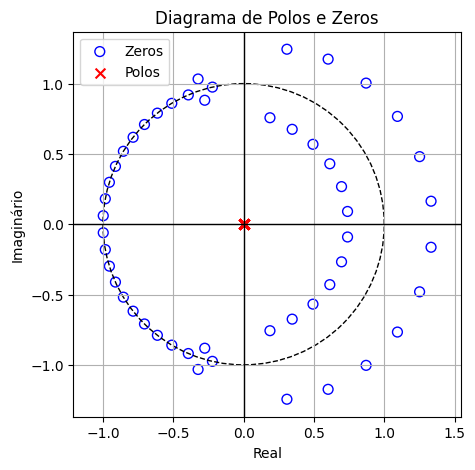


Projetando: M=50, Janela=Blackman


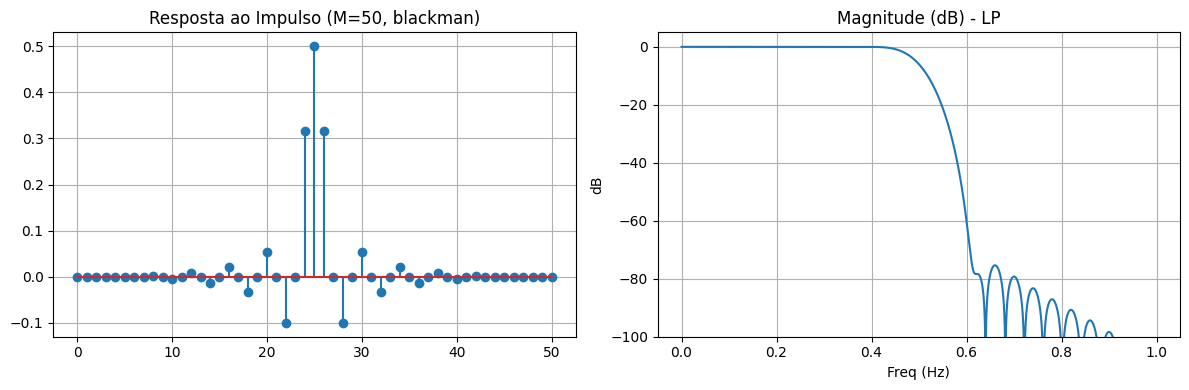

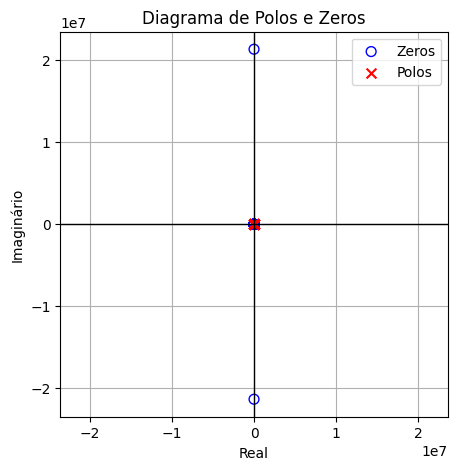


########################################
RESOLVENDO QUESTÃO 2 - ITEM (b)
########################################

Projetando: M=50, Janela=Hamming


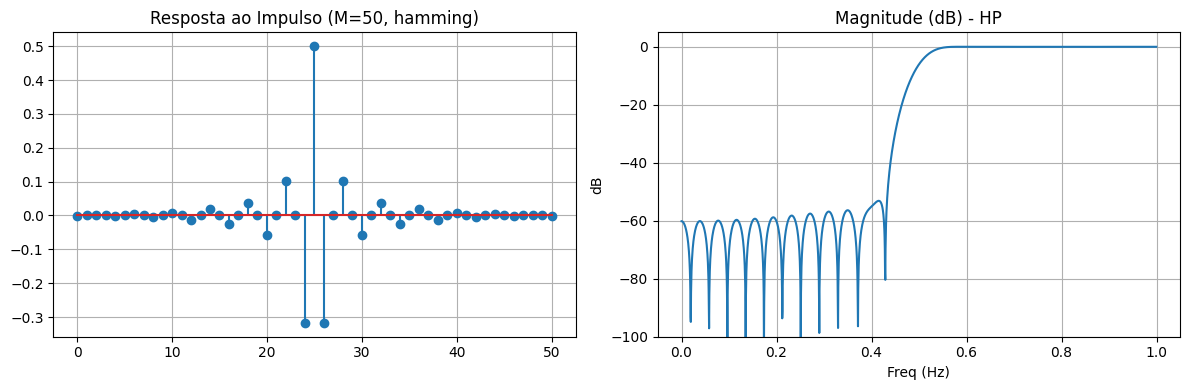

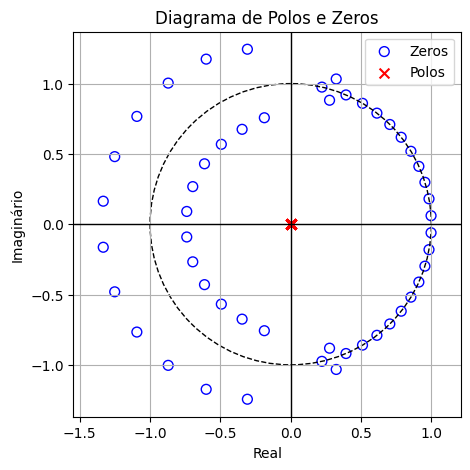


Projetando: M=50, Janela=Blackman


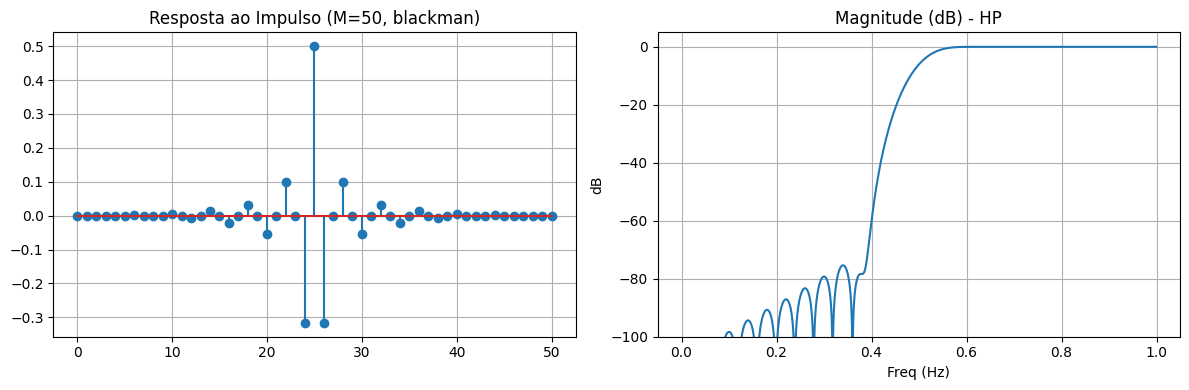

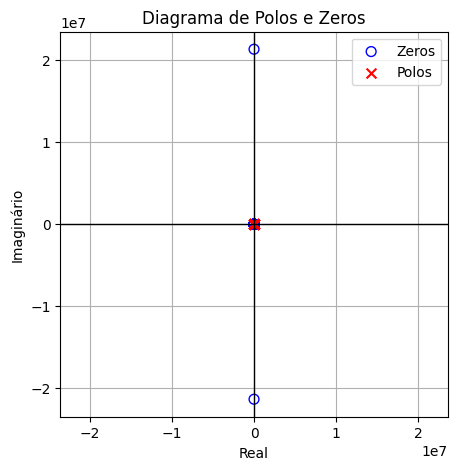

In [6]:
def solve_question_2(item_name, wc_params, M_list=[50, 100], windows=['retangular', 'triangular', 'hamming', 'hann', 'blackman']):
    print(f"\n{'#'*40}\nRESOLVENDO QUESTÃO 2 - ITEM ({item_name})\n{'#'*40}")

    # Mapeamento do item para o tipo de filtro aceito pela função projetar_e_plotar
    filter_map = {'a': 'lp', 'b': 'hp', 'c': 'bp'}
    f_type = filter_map.get(item_name, 'lp')

    for M in M_list:
        for win_name in windows:
            print(f"\nProjetando: M={M}, Janela={win_name.capitalize()}")

            # wc_params são frequências normalizadas (rad/amostra)
            # No projetar_e_plotar, usamos Hz. Como fs=2, f_Hz = wc/pi
            f1_val = wc_params[0]/np.pi if len(wc_params) > 0 else 0
            f2_val = wc_params[1]/np.pi if len(wc_params) > 1 else 0

            # Calculando h para o diagrama de polos e zeros
            wc1 = wc_params[0]
            if f_type == 'lp': h_ideal = ideal_lp(wc1, M)
            elif f_type == 'hp': h_ideal = ideal_lp(np.pi, M) - ideal_lp(wc1, M)
            elif f_type == 'bp':
                wc2 = wc_params[1]
                h_ideal = ideal_lp(wc2, M) - ideal_lp(wc1, M)

            h = h_ideal * get_window(win_name, M)

            # Visualização
            projetar_e_plotar(M, win_name, f_type, fs=2, f1=f1_val, f2=f2_val)
            plot_poles_zeros(h)

# Executando corrigido para os itens principais
solve_question_2('a', [0.5 * np.pi], M_list=[50], windows=['hamming', 'blackman'])
solve_question_2('b', [0.5 * np.pi], M_list=[50], windows=['hamming', 'blackman'])


########################################
RESOLVENDO QUESTÃO 2 - ITEM (c)
########################################

Projetando: M=100, Janela=Hamming


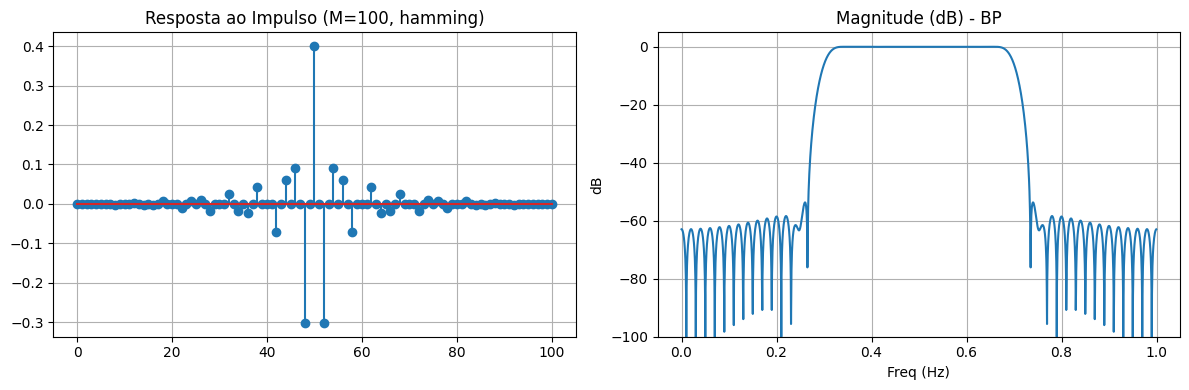

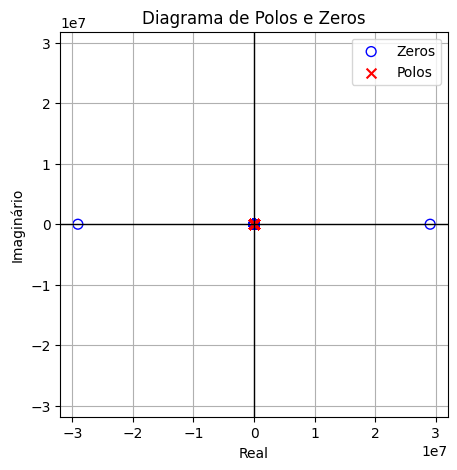


Projetando: M=100, Janela=Blackman


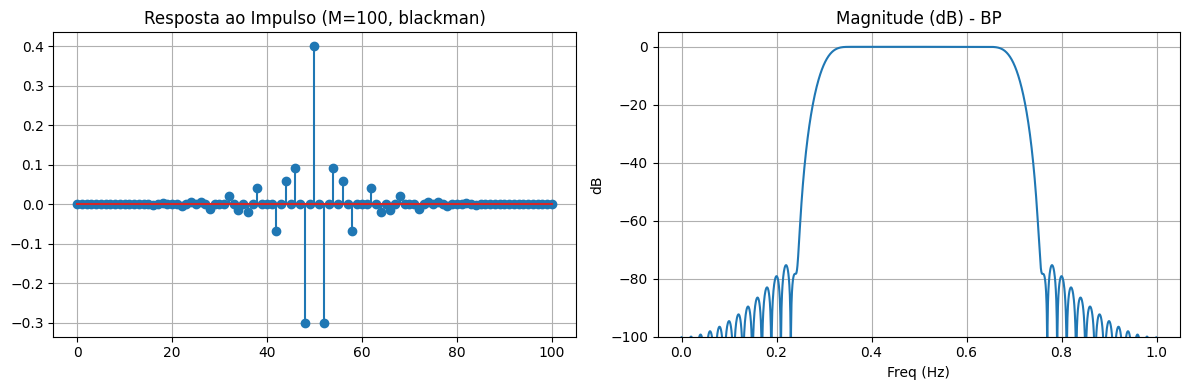

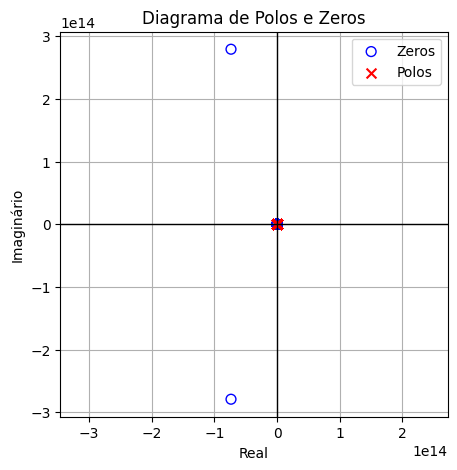

In [7]:
# Resolvendo o Item (c) da Questão 2 - Passa-Faixas
# Frequências sugeridas para o exemplo: wc1 = 0.3*pi e wc2 = 0.7*pi
solve_question_2('c', [0.3 * np.pi, 0.7 * np.pi], M_list=[100], windows=['hamming', 'blackman'])

### Questão 3 - Filtragem de Áudio Real

Nesta etapa, vamos:
1. Gerar o sinal $y(t) = x(t) + 0.05 \cos(200\pi t) + 0.075 \sin(4000\pi t) + n(t)$.
2. Analisar o espectro do sinal ruidoso.
3. Projetar um filtro Rejeita-Faixa ou Passa-Faixa para isolar a voz/música original.

In [8]:
import scipy.io.wavfile as wav
from IPython.display import Audio

# 1. Carregar o arquivo
srate, data = wav.read('/content/handel (1).wav')
data = data.astype(float) / np.max(np.abs(data)) # Normalização
t = np.arange(len(data)) / srate

# 2. Adicionar Interferências
# 0.05*cos(200*pi*t) -> Freq = 100 Hz
# 0.075*sin(4000*pi*t) -> Freq = 2000 Hz
interf_low = 0.05 * np.cos(200 * np.pi * t)
interf_high = 0.075 * np.sin(4000 * np.pi * t)
noise = np.random.normal(0, np.sqrt(0.01), len(data)) # Variância 10^-2

y = data + interf_low + interf_high + noise

print(f"Taxa de amostragem (fs): {srate} Hz")
print("Ouvindo o sinal CONTAMINADO:")
display(Audio(y, rate=srate))

Taxa de amostragem (fs): 8192 Hz
Ouvindo o sinal CONTAMINADO:


Agora, vamos projetar um filtro FIR para limpar o sinal. Como temos ruído em 100Hz e 2000Hz, e o sinal de áudio costuma ocupar uma faixa maior, podemos tentar um filtro **Passa-Faixa** que preserve a região de interesse ou filtros **Rejeita-Faixa** específicos para as frequências tonais.

Ouvindo o sinal RECUPERADO (Filtrado):


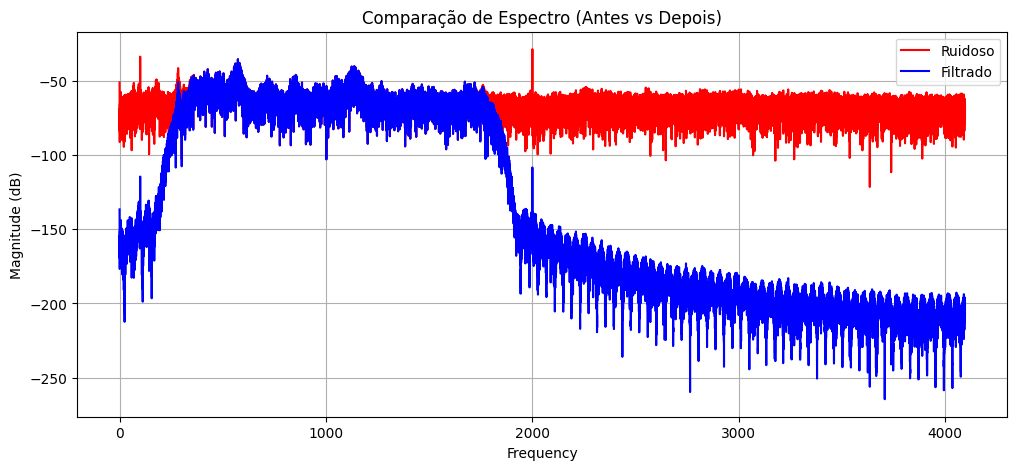

In [9]:
# 3. Projeto do Filtro para Recuperação
# Vamos remover a interferência de 100Hz e 2000Hz
# Estratégia: Filtro Passa-Faixas entre 300Hz e 1800Hz para teste didático

M = 200 # Ordem maior para melhor seletividade
win = get_window('blackman', M)

# Definindo frequências de corte para o Passa-Faixas
fc1 = 300
fc2 = 1800
wc1 = 2 * np.pi * fc1 / srate
wc2 = 2 * np.pi * fc2 / srate

h_ideal = ideal_lp(wc2, M) - ideal_lp(wc1, M)
h_final = h_ideal * win

# Aplicando o filtro via convolução
y_filtered = np.convolve(y, h_final, mode='same')

print("Ouvindo o sinal RECUPERADO (Filtrado):")
display(Audio(y_filtered, rate=srate))

# Comparando espectros
plt.figure(figsize=(12, 5))
plt.magnitude_spectrum(y, Fs=srate, scale='dB', color='r', label='Ruidoso')
plt.magnitude_spectrum(y_filtered, Fs=srate, scale='dB', color='b', label='Filtrado')
plt.title('Comparação de Espectro (Antes vs Depois)')
plt.legend()
plt.grid(True)
plt.show()

### Questão 1 - Itens (c) e (d)
Nesta célula, projetamos o filtro **Passa-Faixas** e o **Rejeita-Faixa** para comparar o desempenho das janelas de Hamming e Blackman com a Retangular.


########################################
ITEM (c) - PASSA-FAIXAS (500-2000 Hz)
########################################


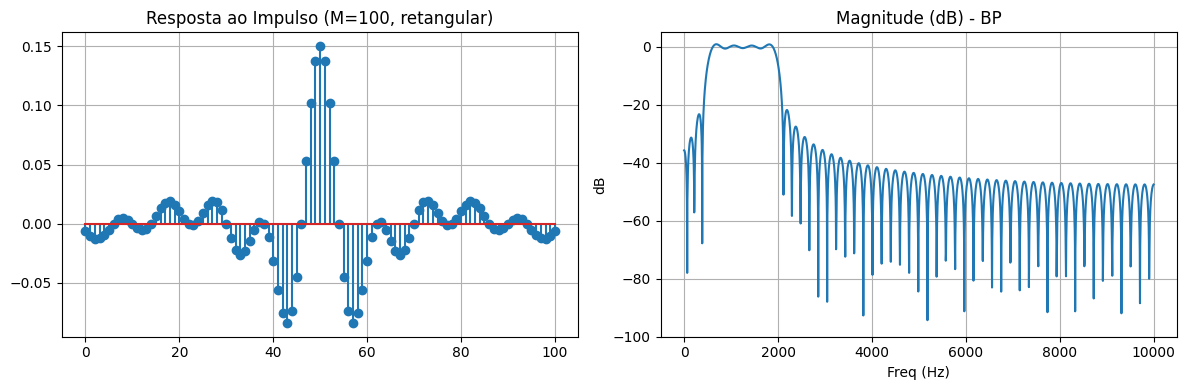

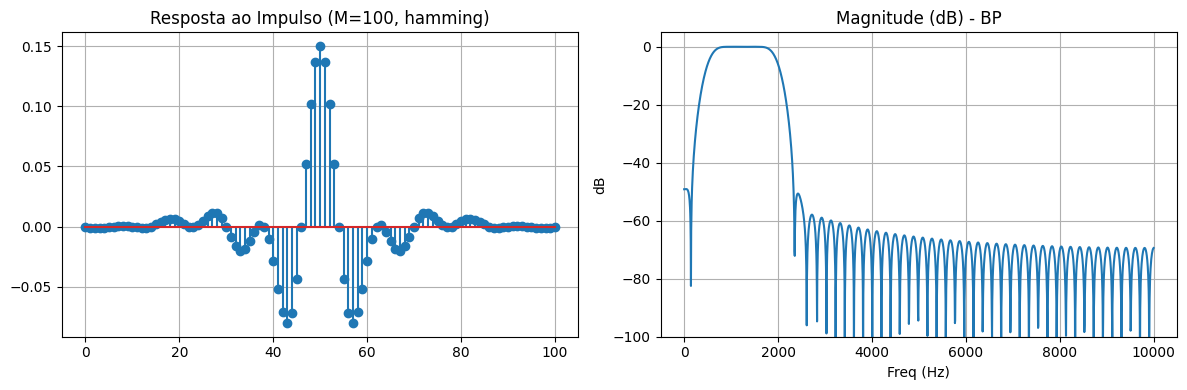

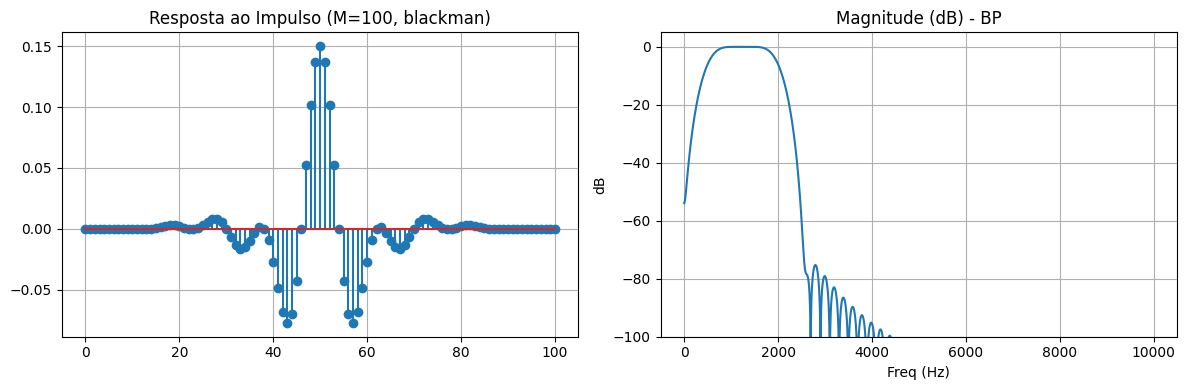


########################################
ITEM (d) - REJEITA-FAIXA (1000-2500 Hz)
########################################


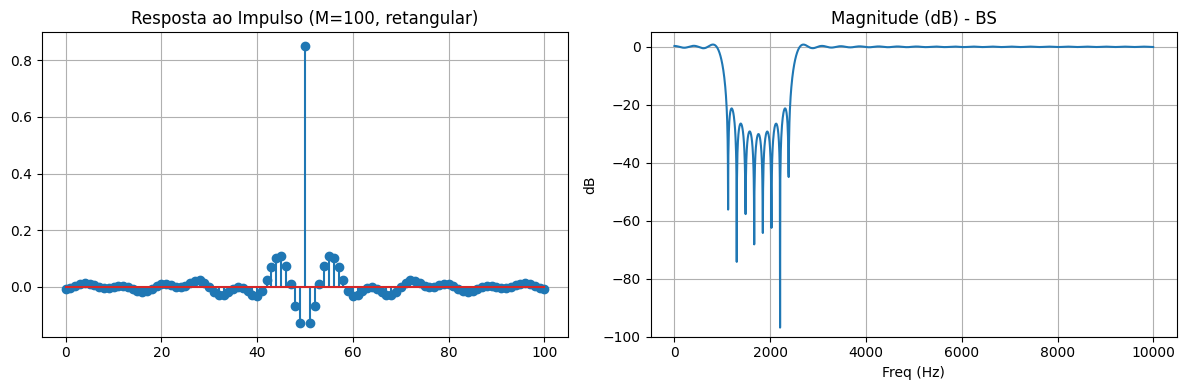

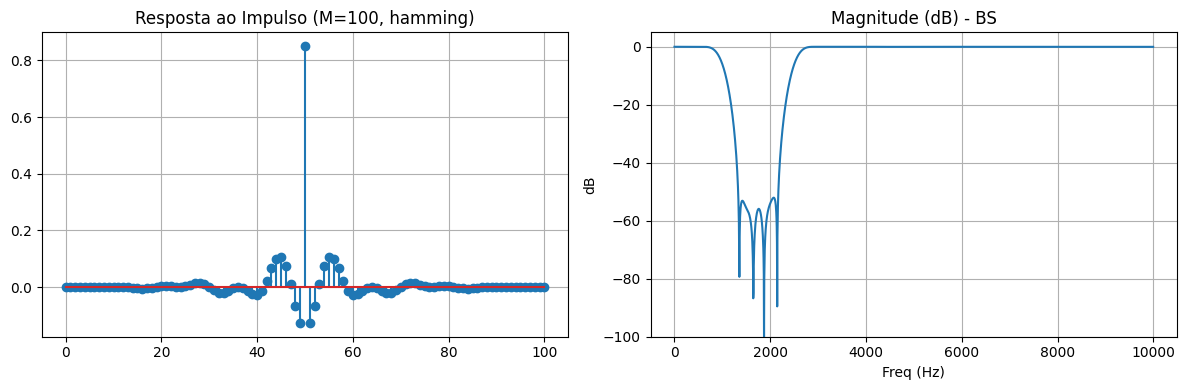

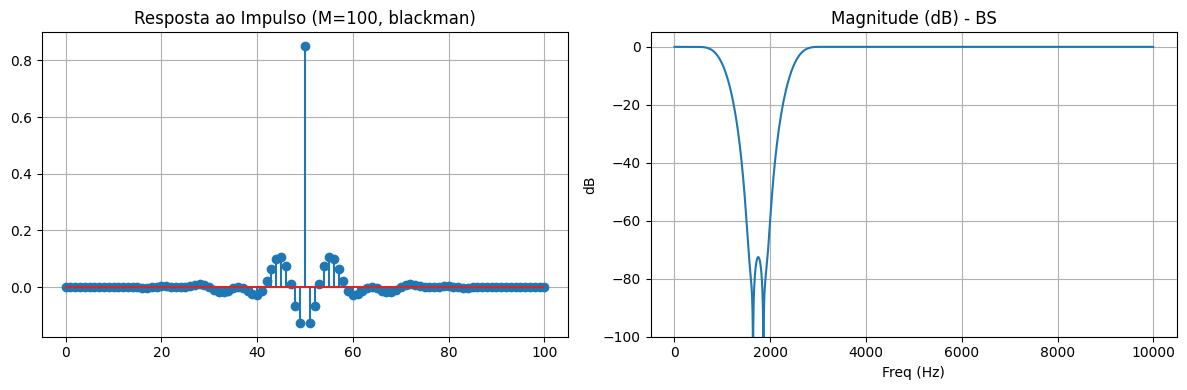

In [15]:
fs = 20000
M = 100
janelas_foco = ['retangular', 'hamming', 'blackman']

# --- Item (c) Passa-Faixas (500Hz - 2000Hz) ---
print(f'\n' + '#'*40 + '\nITEM (c) - PASSA-FAIXAS (500-2000 Hz)\n' + '#'*40)
for win in janelas_foco:
    projetar_e_plotar(M, win, 'bp', fs=fs, f1=500, f2=2000)

# --- Item (d) Rejeita-Faixa (1000Hz - 2500Hz) ---
print(f'\n' + '#'*40 + '\nITEM (d) - REJEITA-FAIXA (1000-2500 Hz)\n' + '#'*40)
for win in janelas_foco:
    projetar_e_plotar(M, win, 'bs', fs=fs, f1=1000, f2=2500)

### Item (e) - Análise Comparativa e Conclusões

Com base nos experimentos realizados nos itens (a) a (d), podemos concluir que:

1.  **Largura de Transição**: A janela **Retangular** sempre apresenta a transição mais estreita (mais 'rápida') para uma mesma ordem $M$. No entanto, seu custo é um alto ripple na banda passante e baixa atenuação na banda de rejeição.
2.  **Atenuação de Banda de Rejeição**: A janela de **Blackman** é a mais eficiente em 'silenciar' frequências indesejadas, atingindo atenuações muito superiores a 60 dB, seguida pela **Hamming**.
3.  **Fenômeno de Gibbs**: O uso de janelas (apodização) é essencial para reduzir as oscilações causadas pelo truncamento abrupto da série de Fourier da resposta ao impulso ideal.
4.  **Estabilidade**: Por serem filtros **FIR**, todos os projetos resultam em sistemas inerentemente estáveis e de fase linear, garantindo que não haja distorção de fase no sinal processado.

### Questão 1 - Item (a)
**Projeto de Filtro Passa-Baixas**
- $f_s = 20000$ Hz
- $f_c = 1000$ Hz
- $M \in \{20, 50, 100\}$
- Janelas: Retangular, Triangular, Bartlett, Hamming, Hann, Blackman.


ANÁLISE PARA ORDEM M = 20

--- Janela: RETANGULAR ---


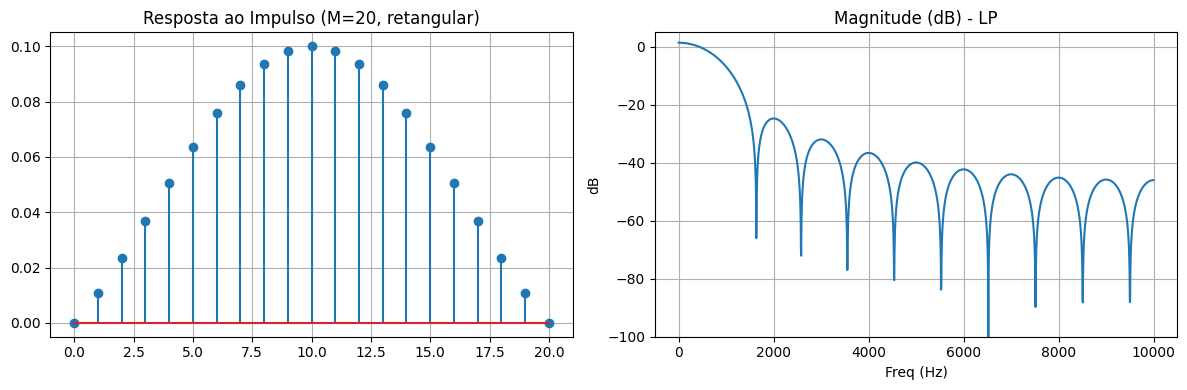

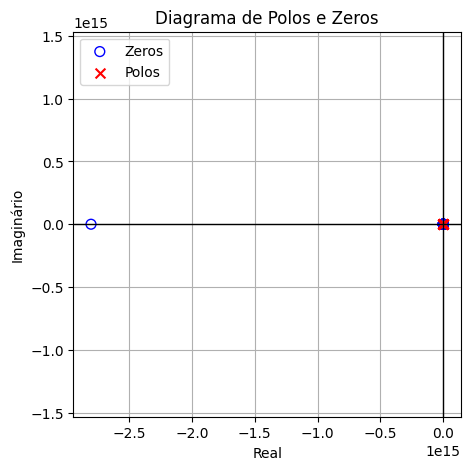


--- Janela: TRIANGULAR ---


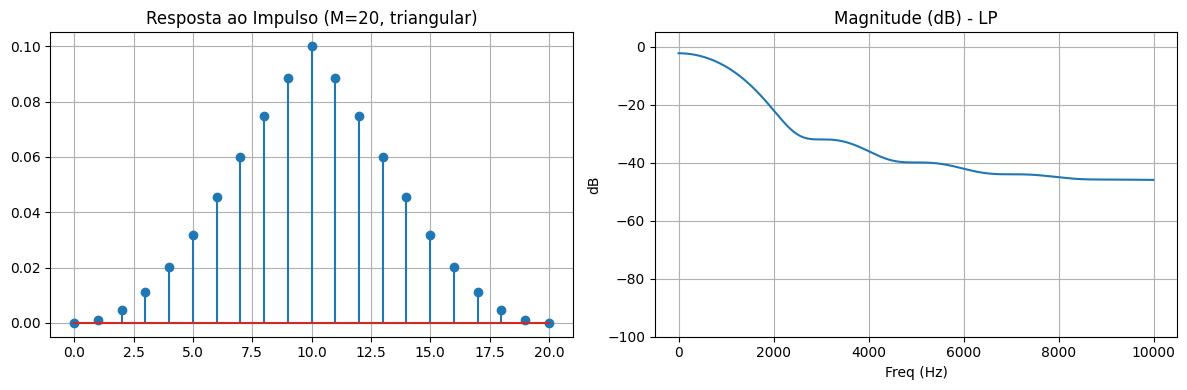

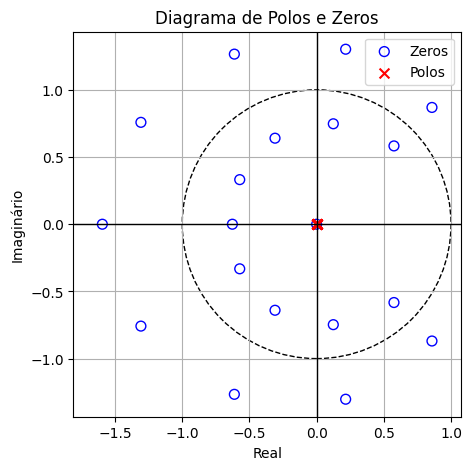


--- Janela: BARTLETT ---


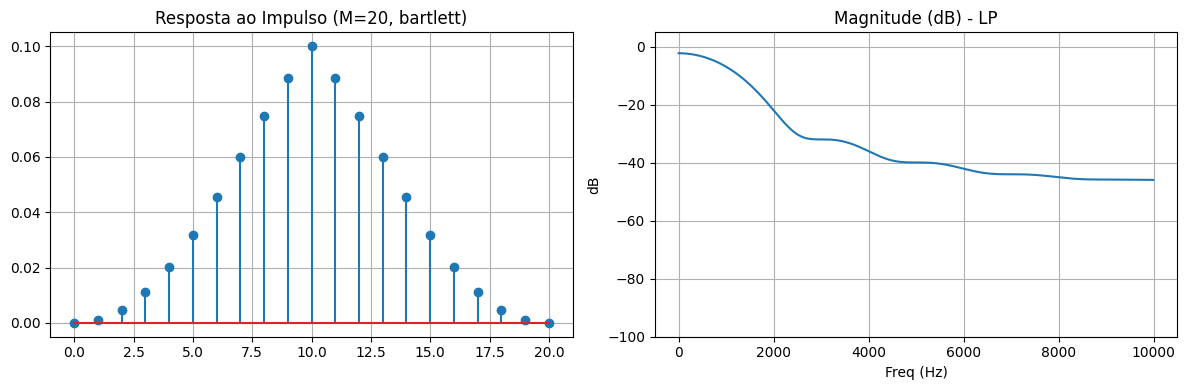

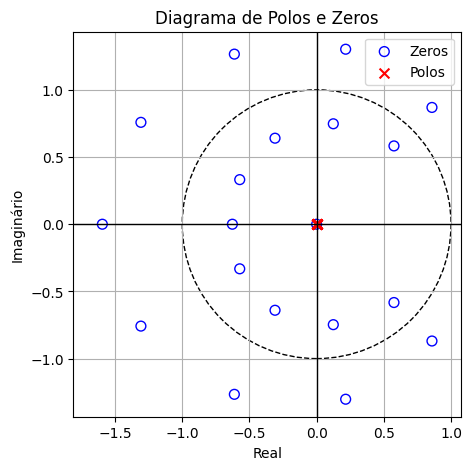


--- Janela: HAMMING ---


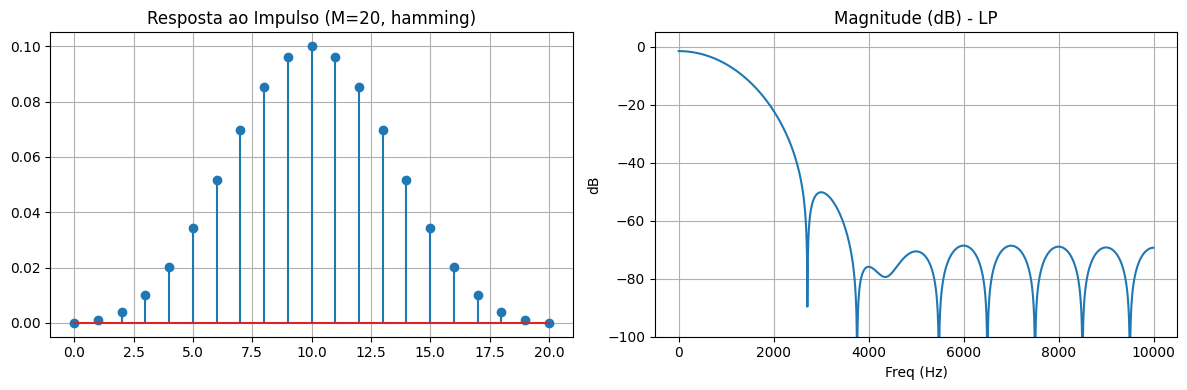

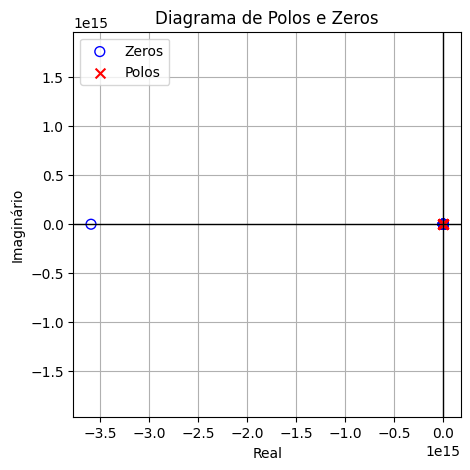


--- Janela: HANN ---


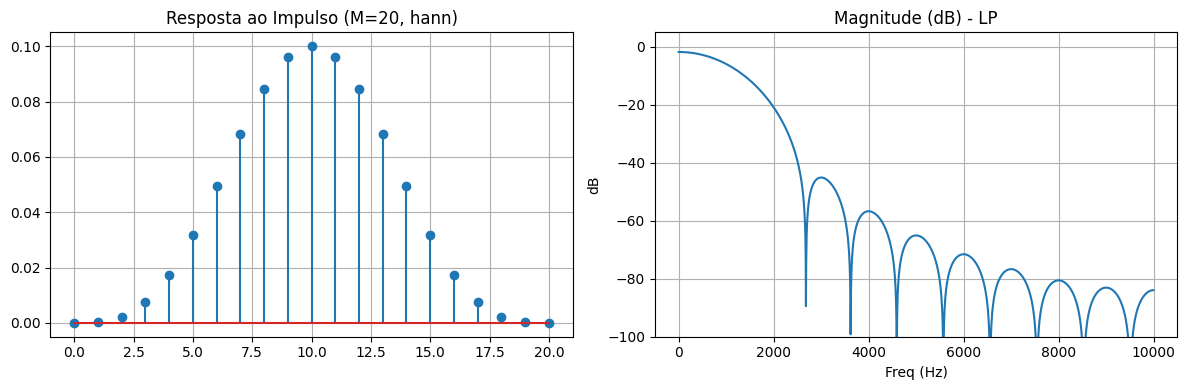

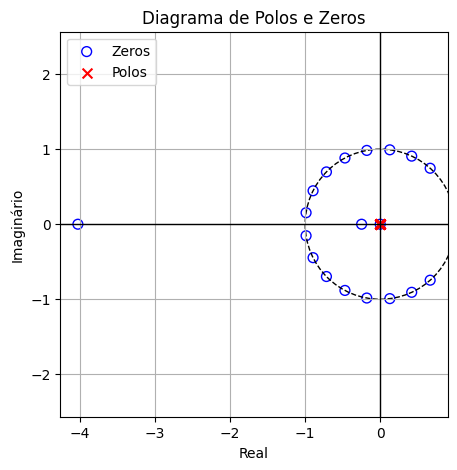


--- Janela: BLACKMAN ---


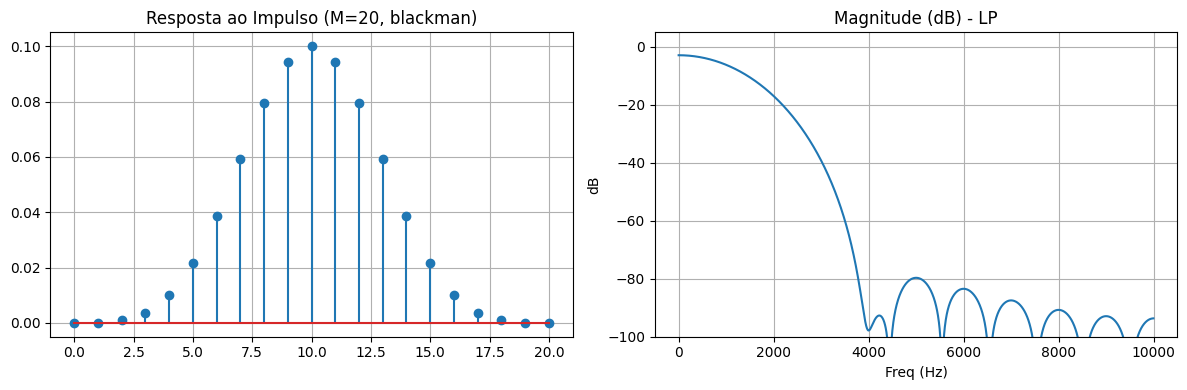

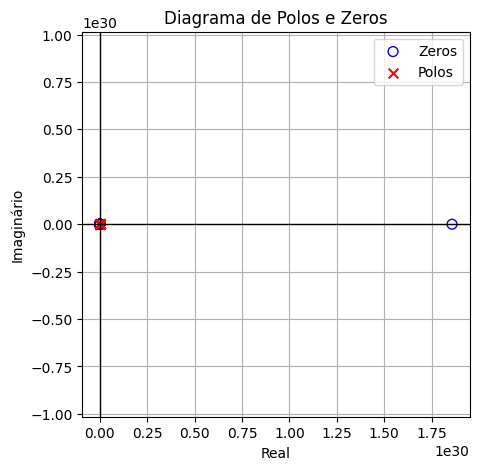


ANÁLISE PARA ORDEM M = 50

--- Janela: RETANGULAR ---


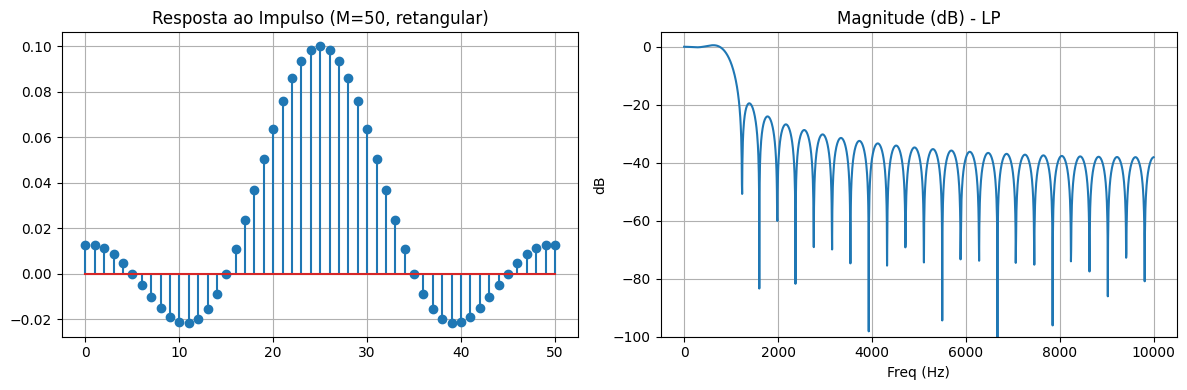

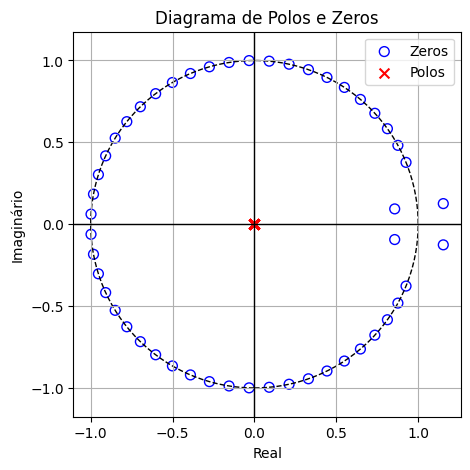


--- Janela: TRIANGULAR ---


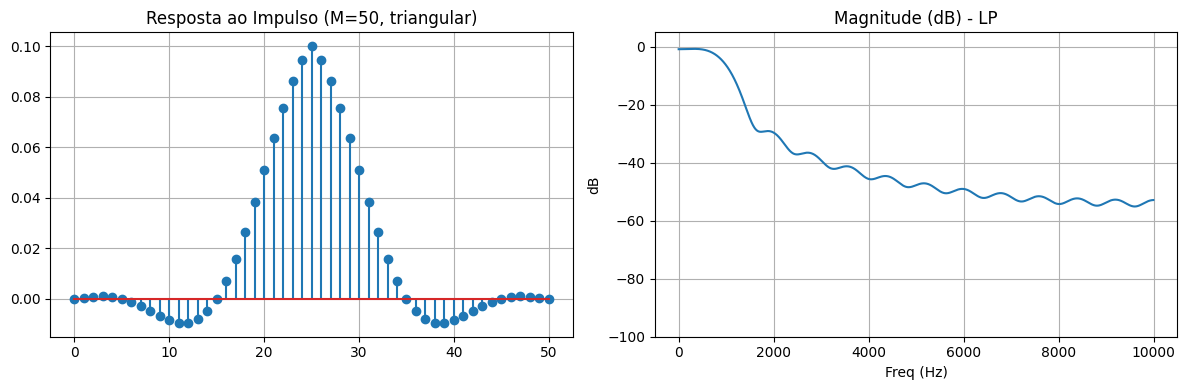

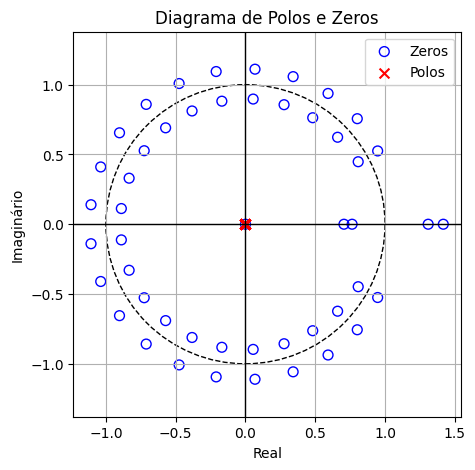


--- Janela: BARTLETT ---


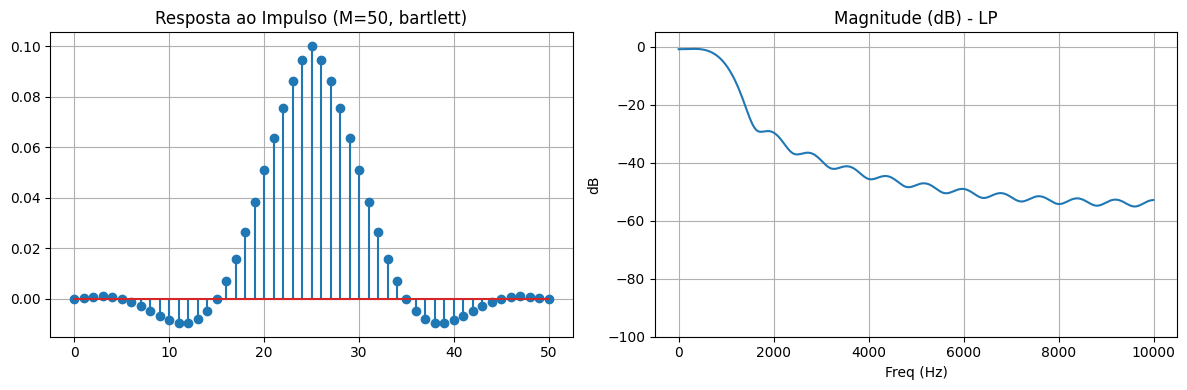

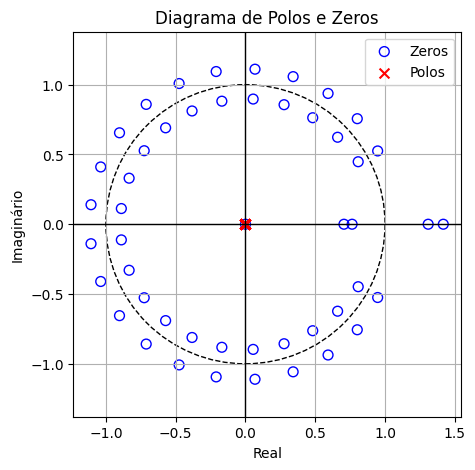


--- Janela: HAMMING ---


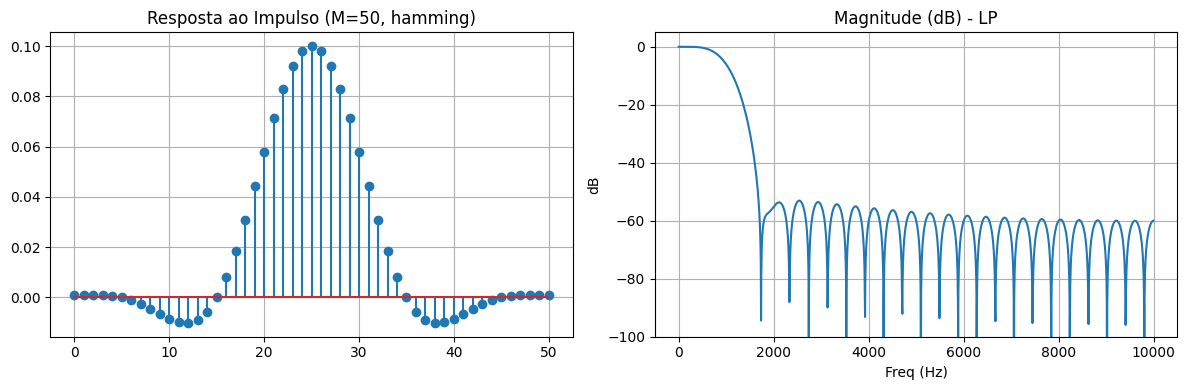

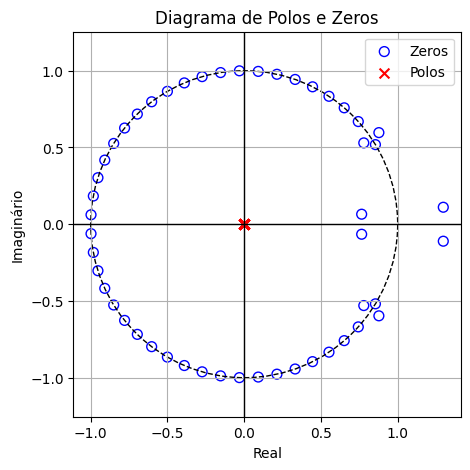


--- Janela: HANN ---


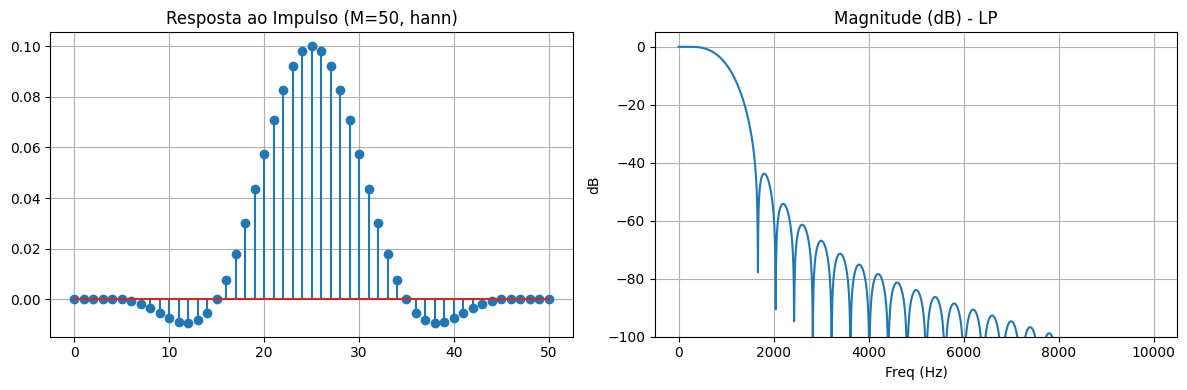

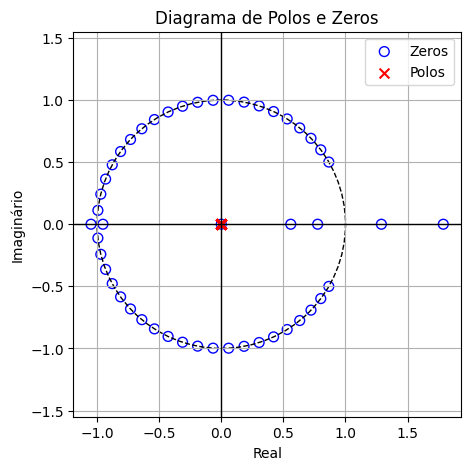


--- Janela: BLACKMAN ---


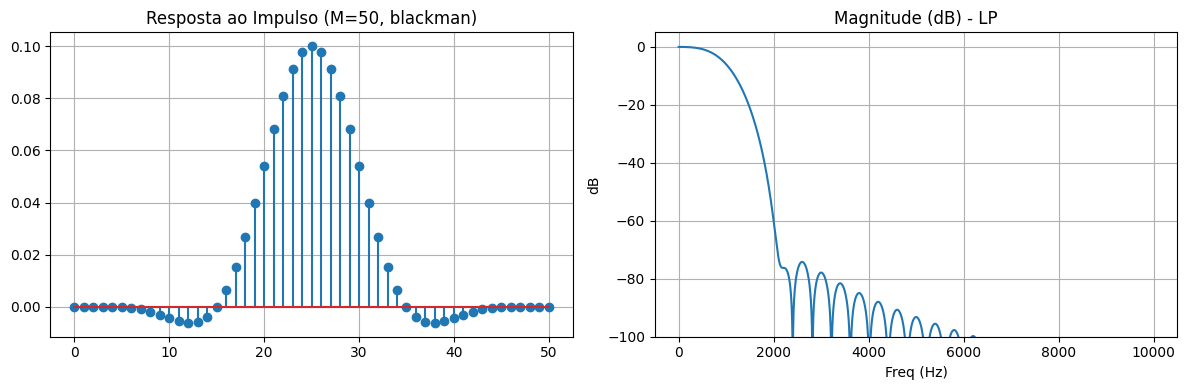

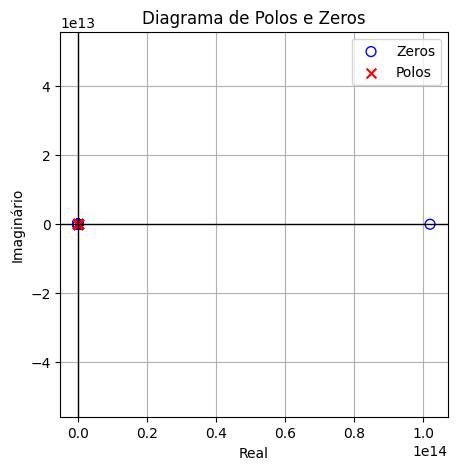


ANÁLISE PARA ORDEM M = 100

--- Janela: RETANGULAR ---


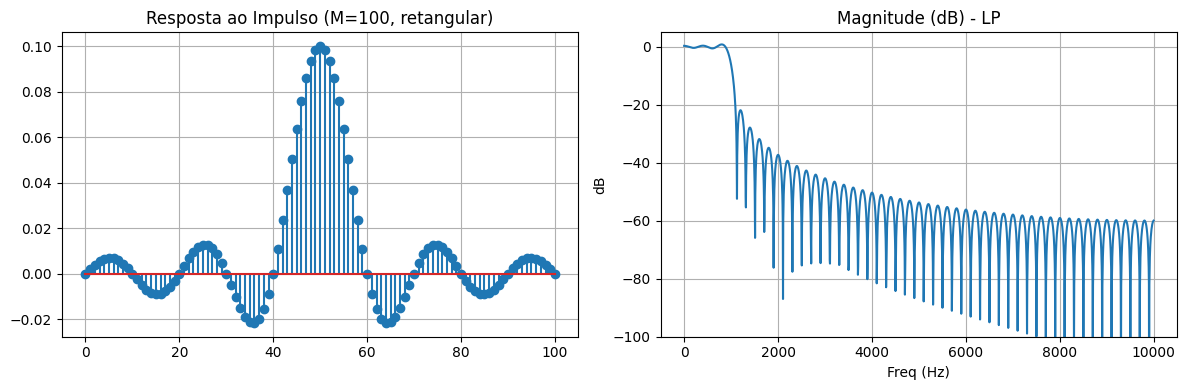

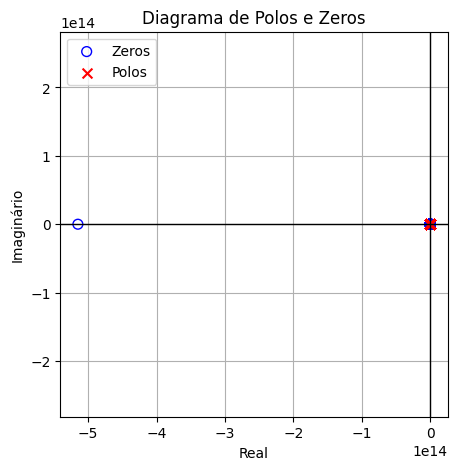


--- Janela: TRIANGULAR ---


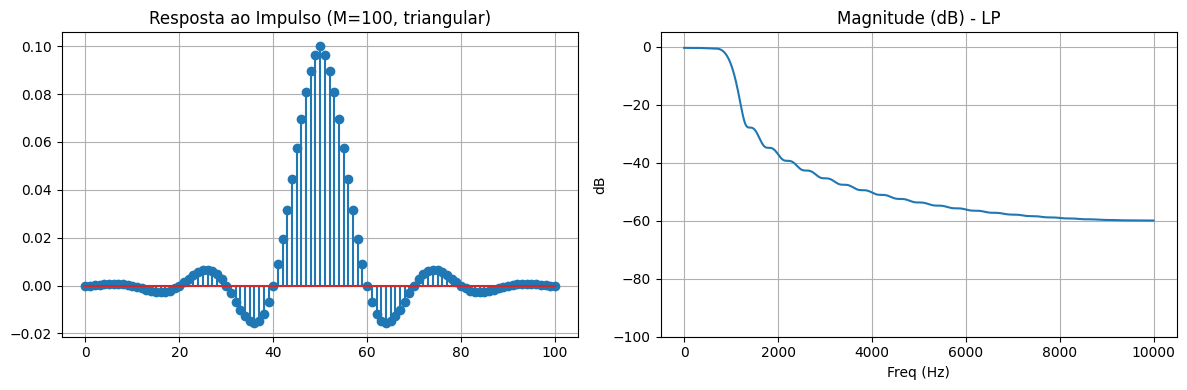

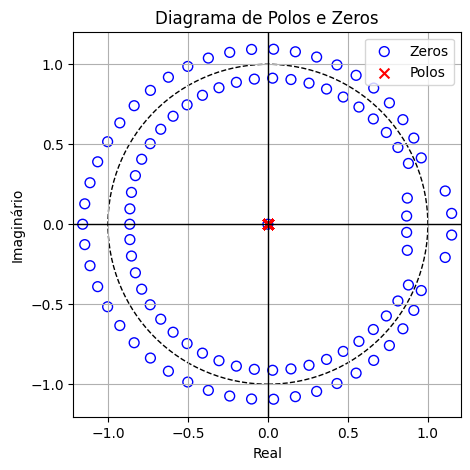


--- Janela: BARTLETT ---


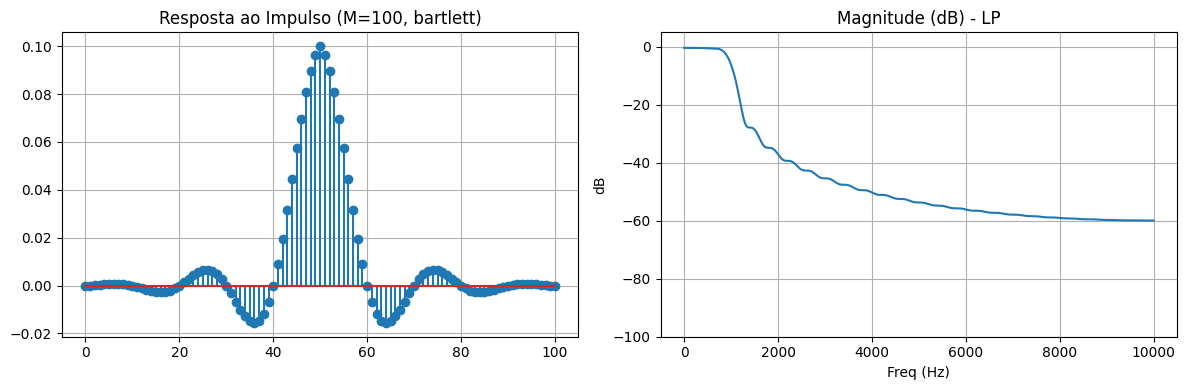

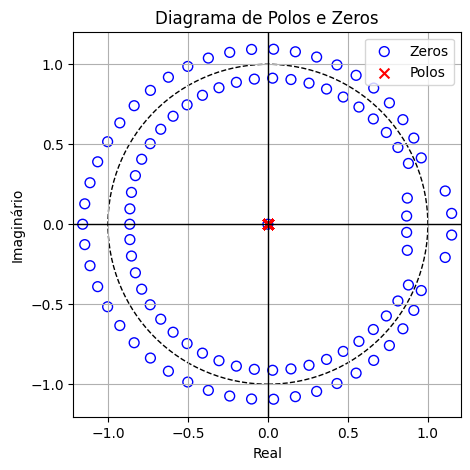


--- Janela: HAMMING ---


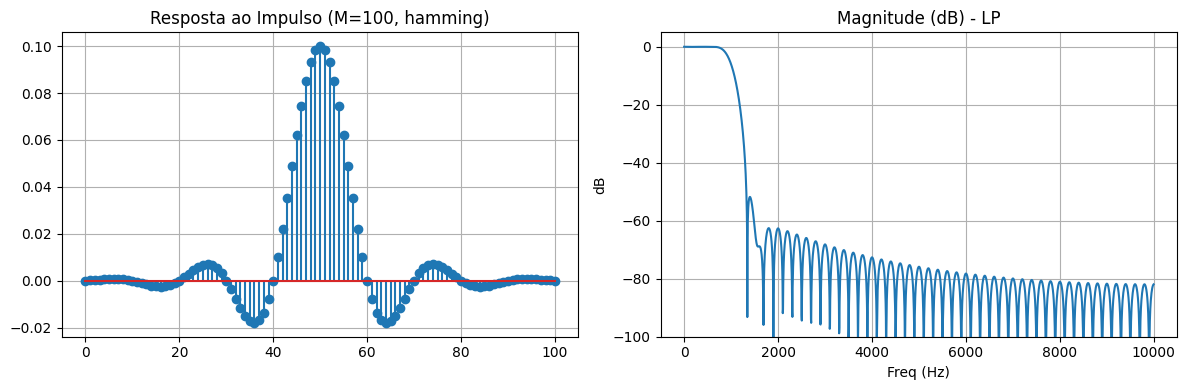

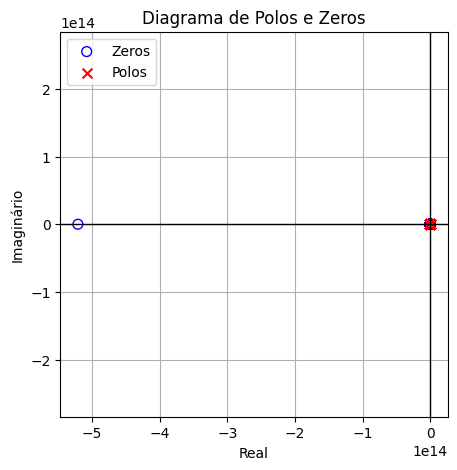


--- Janela: HANN ---


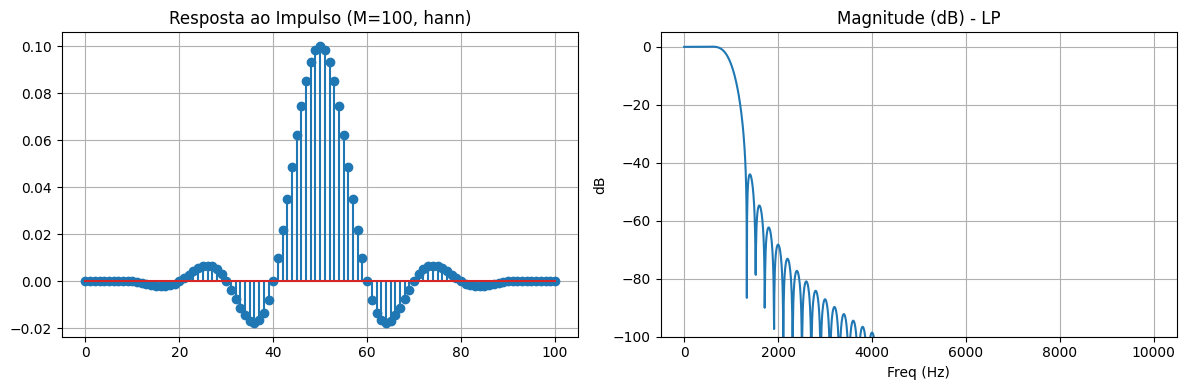

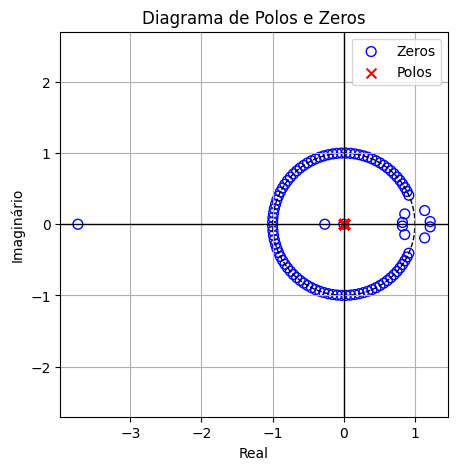


--- Janela: BLACKMAN ---


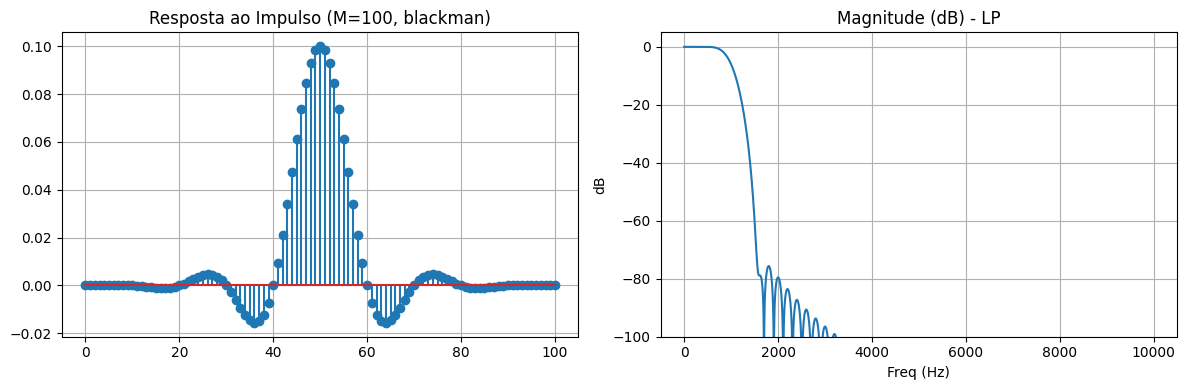

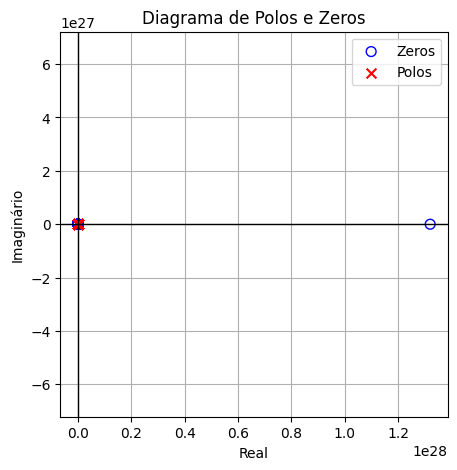

In [11]:
fs = 20000
fc = 1000
wc = 2 * np.pi * fc / fs

# Lista de ordens e janelas para análise completa do item (a)
ordens = [20, 50, 100]
janelas = ['retangular', 'triangular', 'bartlett', 'hamming', 'hann', 'blackman']

for m_val in ordens:
    print(f'\n' + '='*50)
    print(f'ANÁLISE PARA ORDEM M = {m_val}')
    print('='*50)

    for win_name in janelas:
        print(f'\n--- Janela: {win_name.upper()} ---')

        # Calculando a resposta ao impulso h[n] final
        h_ideal = ideal_lp(wc, m_val)
        win = get_window(win_name, m_val)
        h_final = h_ideal * win

        # Visualização: Resposta ao Impulso e Magnitude em dB
        projetar_e_plotar(m_val, win_name, 'lp', fs=fs, f1=fc)

        # Visualização: Diagrama de Polos e Zeros
        plot_poles_zeros(h_final)

### Questão 1 - Item (b)
**Projeto de Filtro Passa-Altas**
- $f_s = 20000$ Hz
- $f_c = 2000$ Hz
- $M \in \{20, 50, 100\}$
- Janelas: Retangular, Triangular, Bartlett, Hamming, Hann, Blackman.


ANÁLISE PASSA-ALTAS: M = 20

--- Janela: RETANGULAR ---


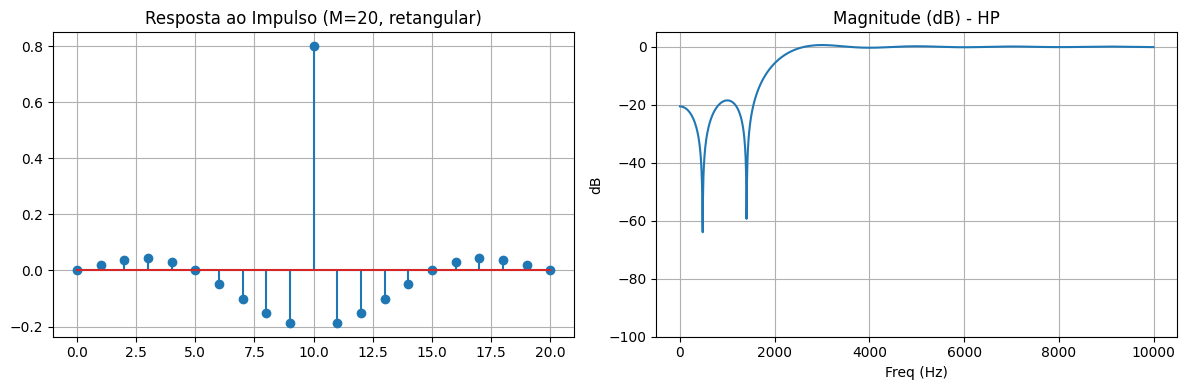

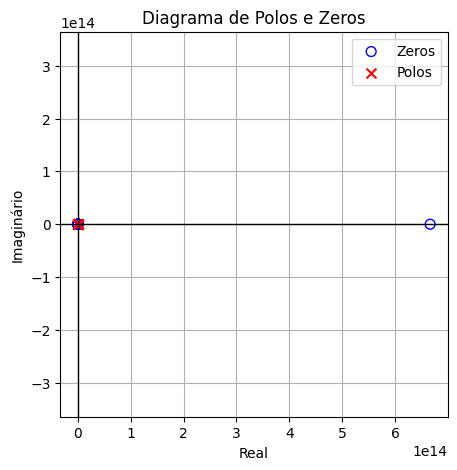


--- Janela: TRIANGULAR ---


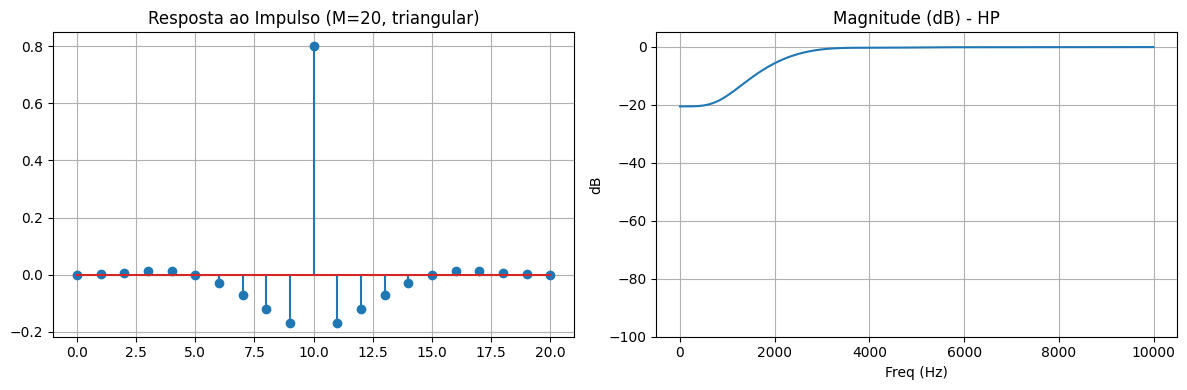

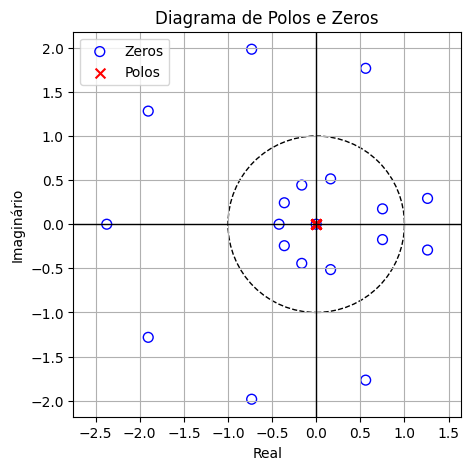


--- Janela: BARTLETT ---


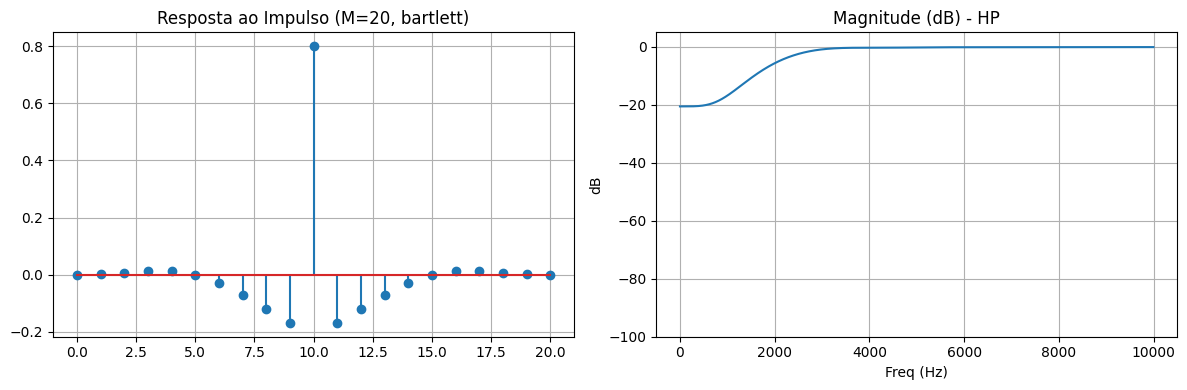

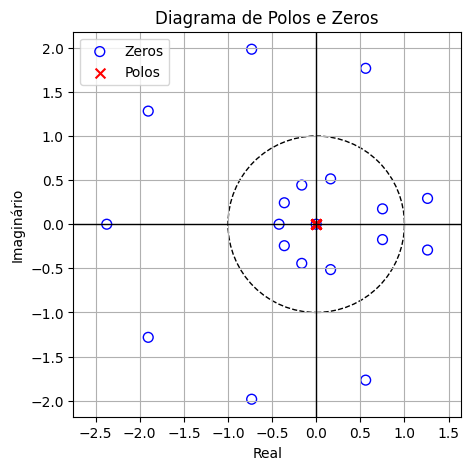


--- Janela: HAMMING ---


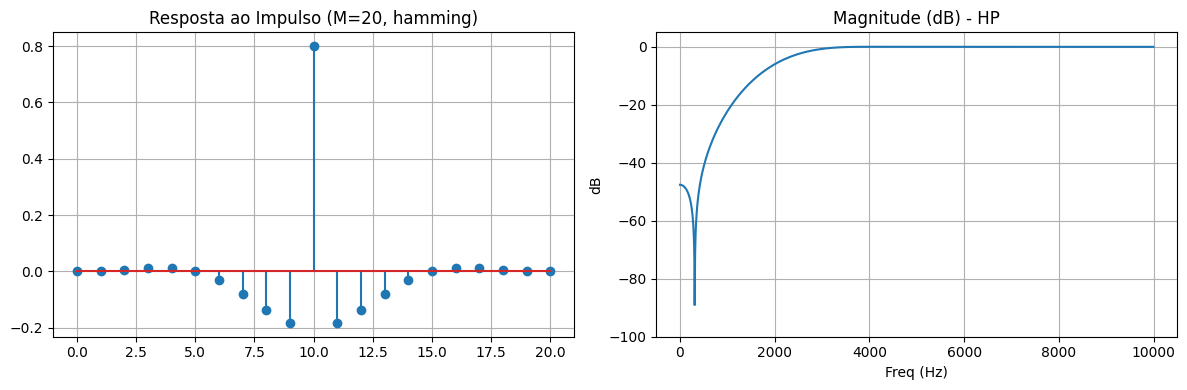

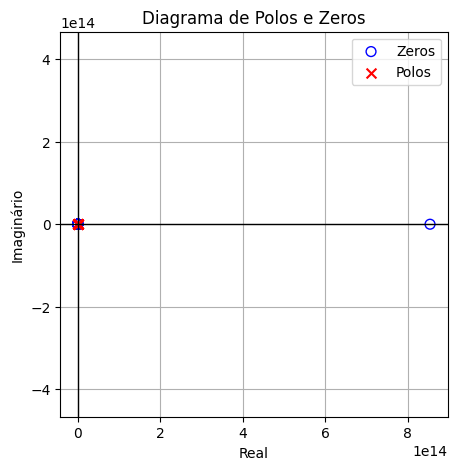


--- Janela: HANN ---


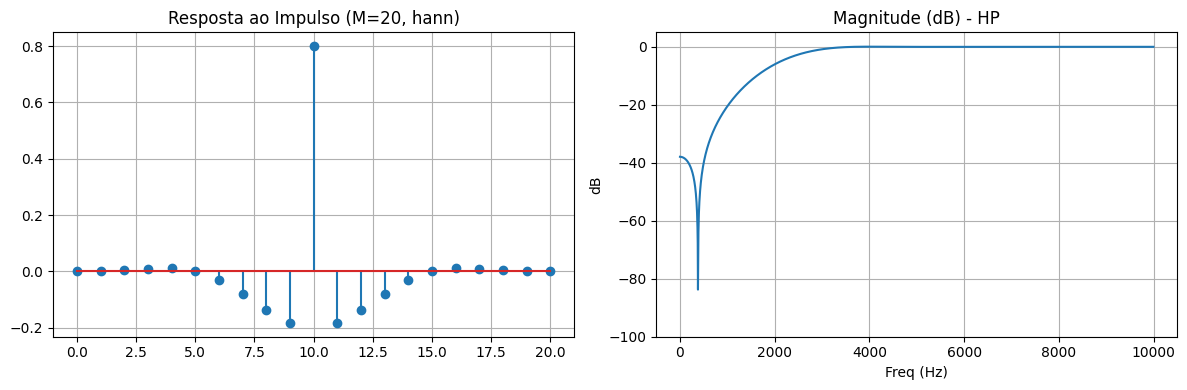

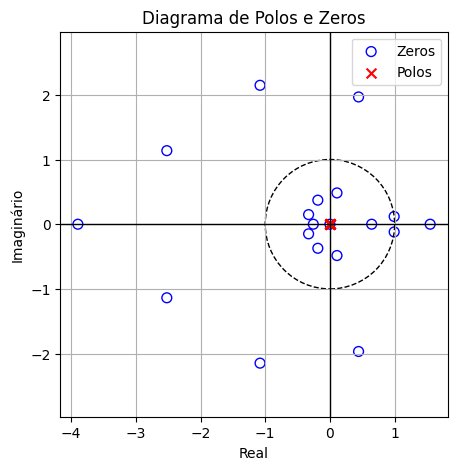


--- Janela: BLACKMAN ---


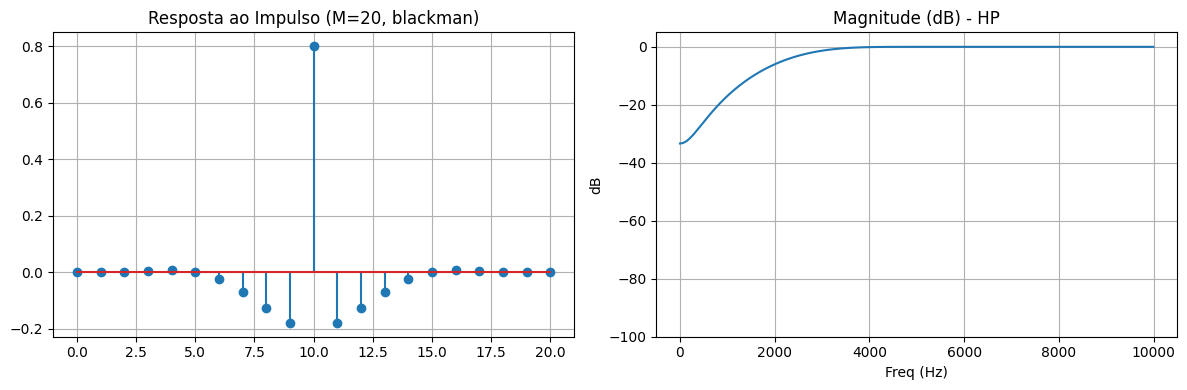

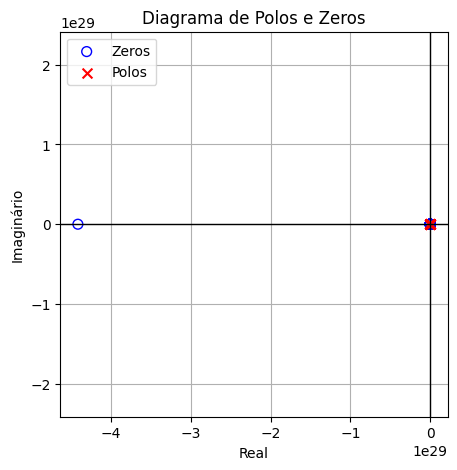


ANÁLISE PASSA-ALTAS: M = 50

--- Janela: RETANGULAR ---


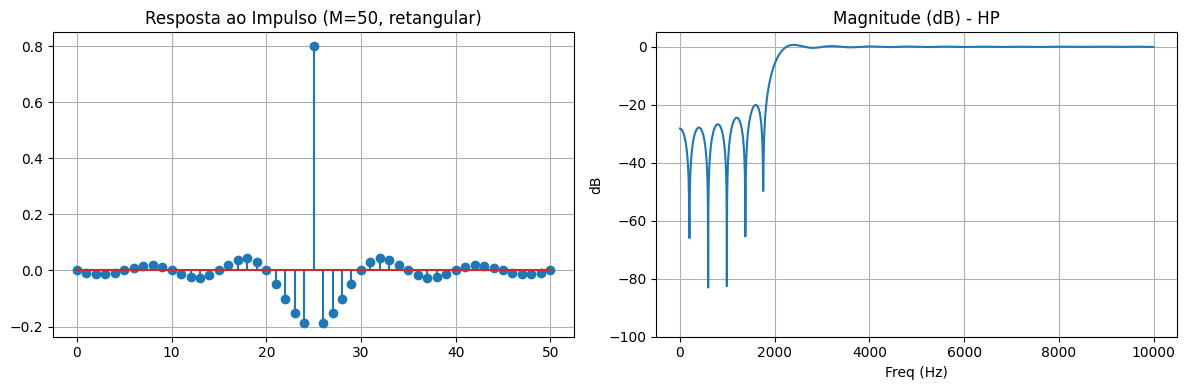

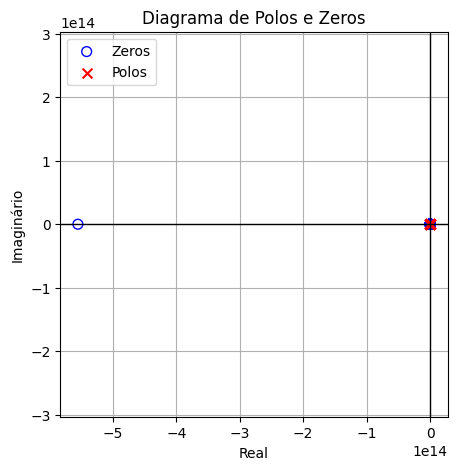


--- Janela: TRIANGULAR ---


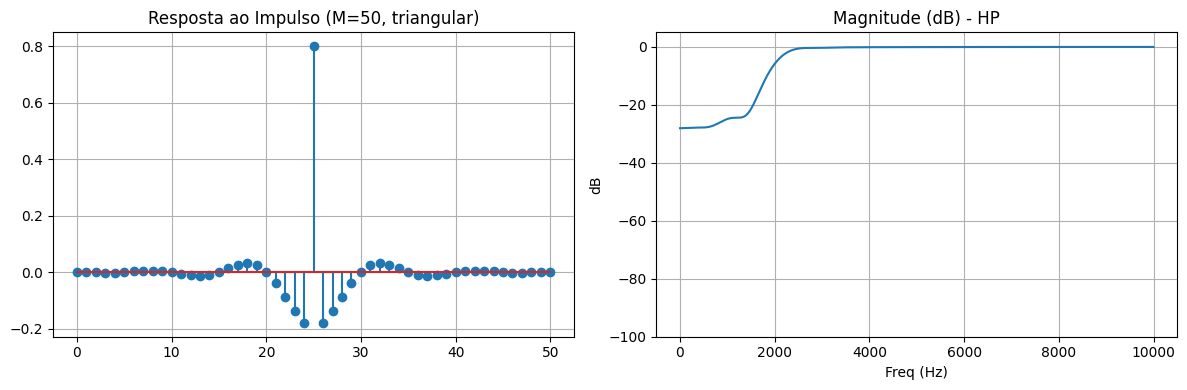

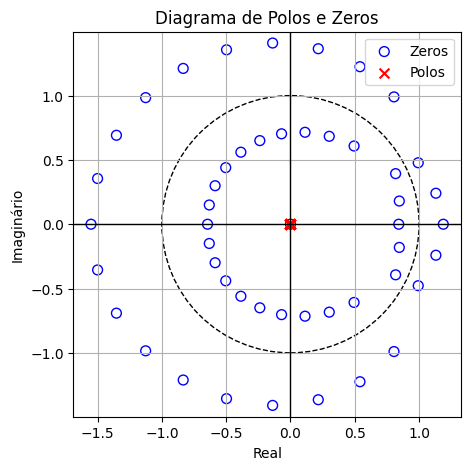


--- Janela: BARTLETT ---


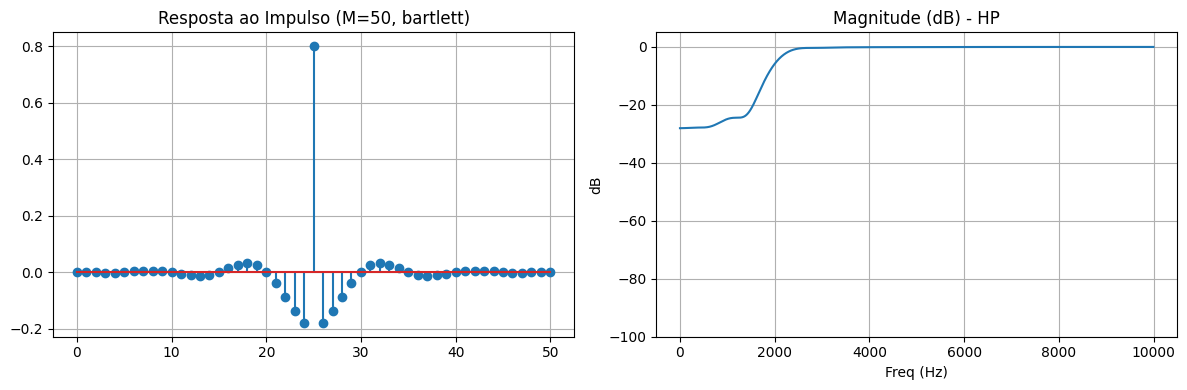

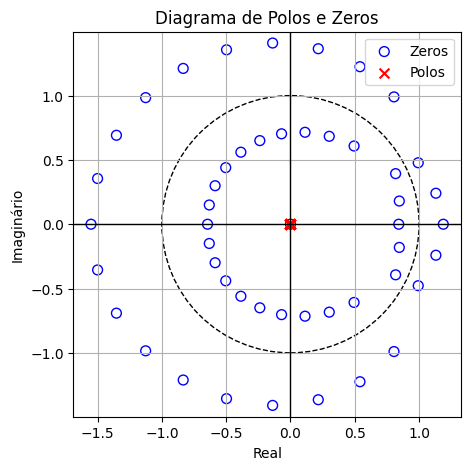


--- Janela: HAMMING ---


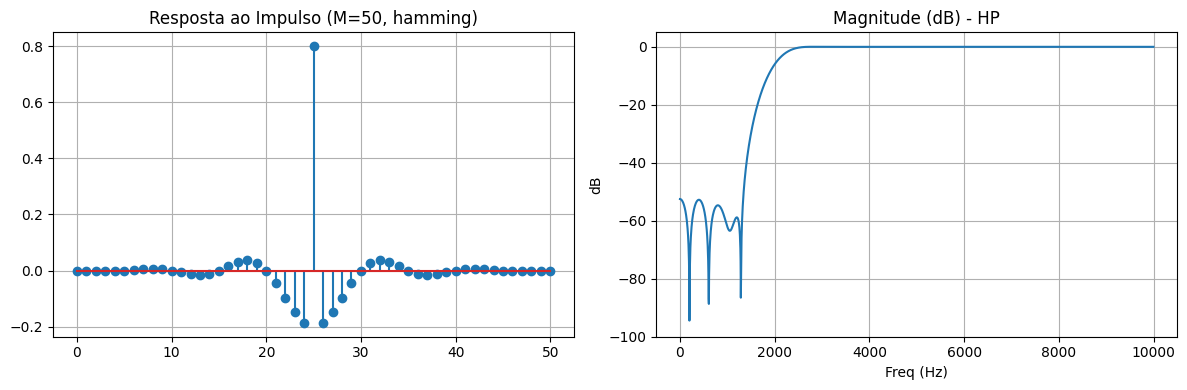

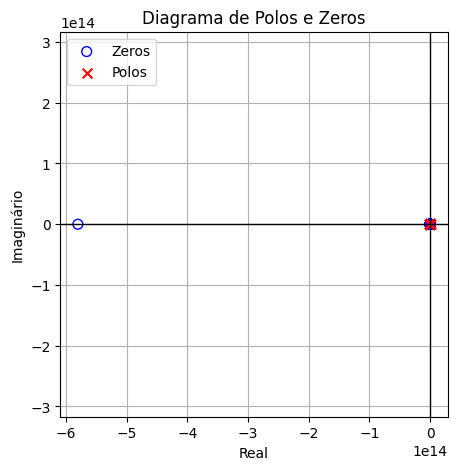


--- Janela: HANN ---


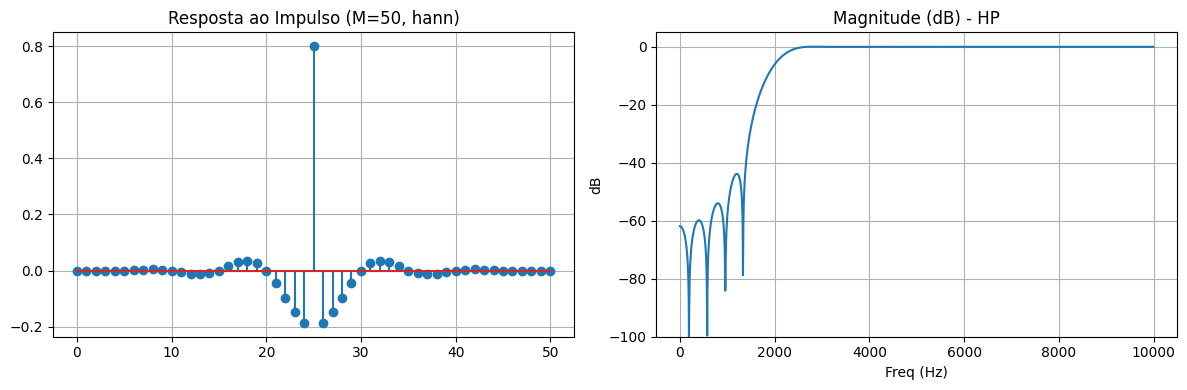

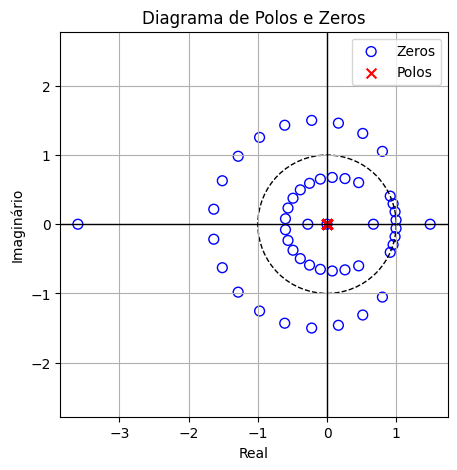


--- Janela: BLACKMAN ---


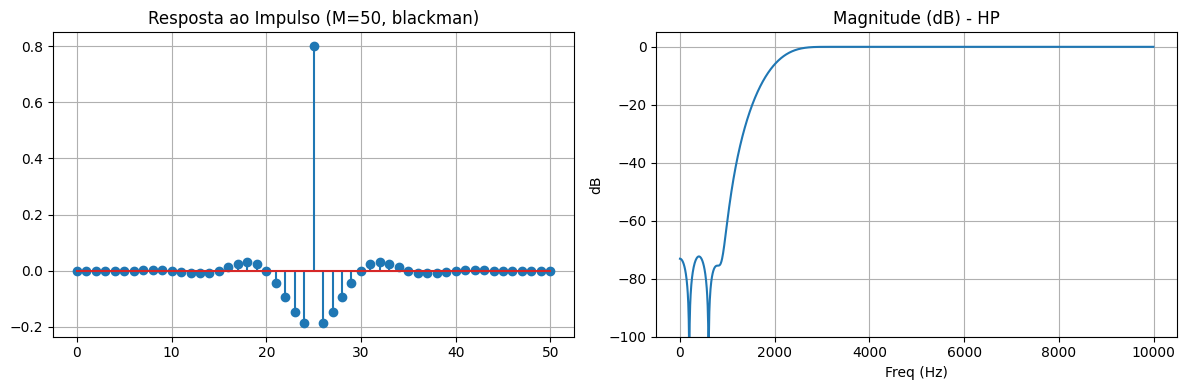

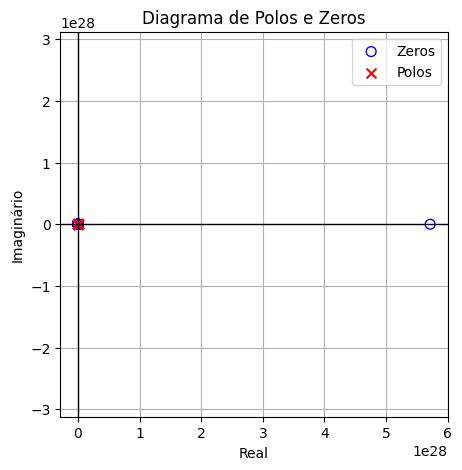


ANÁLISE PASSA-ALTAS: M = 100

--- Janela: RETANGULAR ---


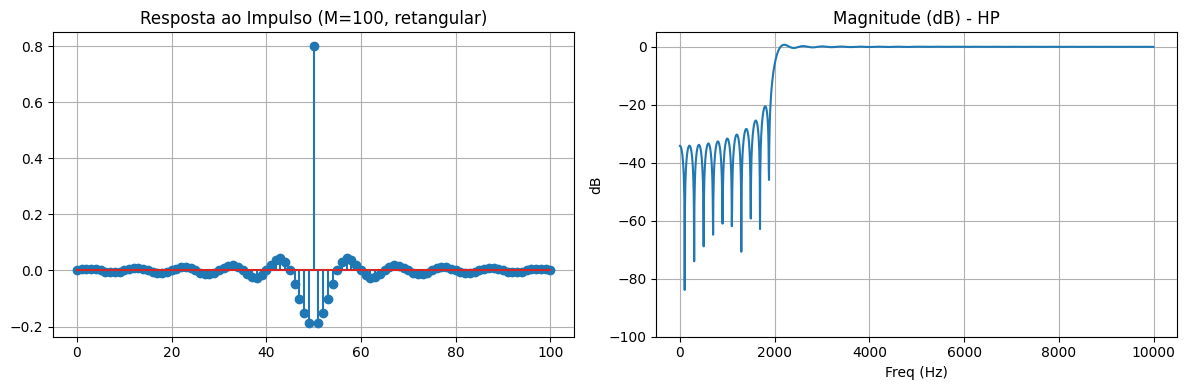

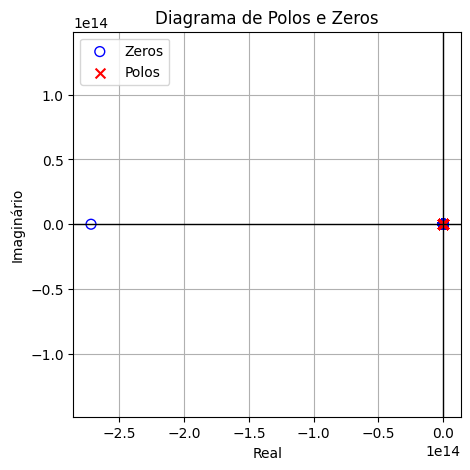


--- Janela: TRIANGULAR ---


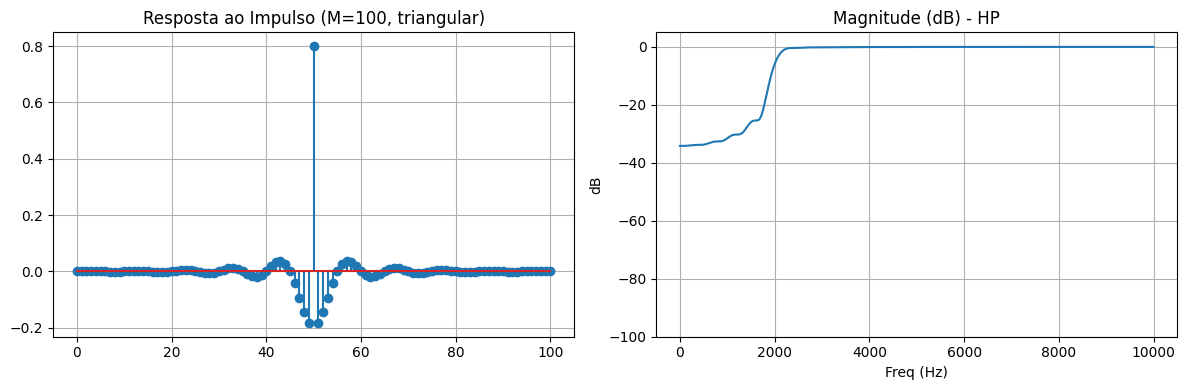

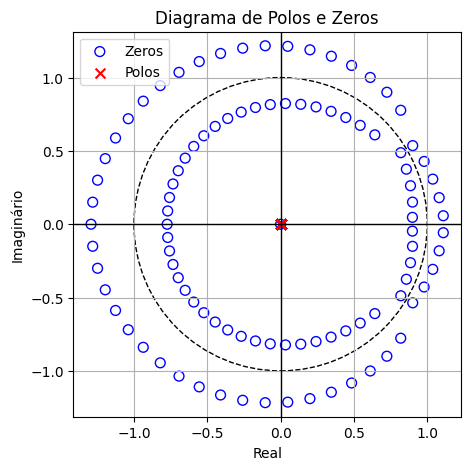


--- Janela: BARTLETT ---


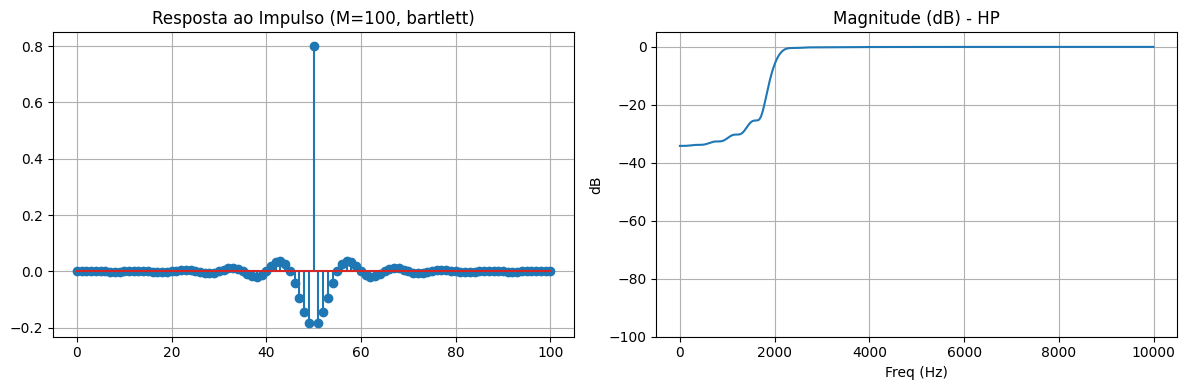

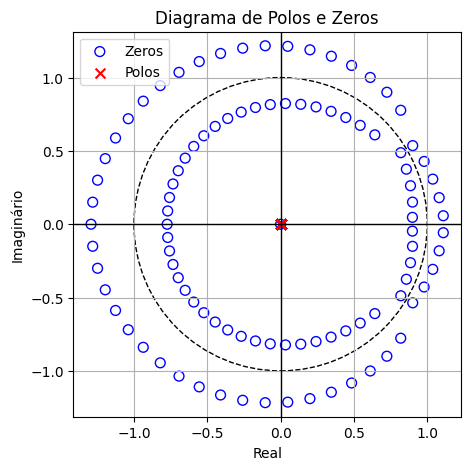


--- Janela: HAMMING ---


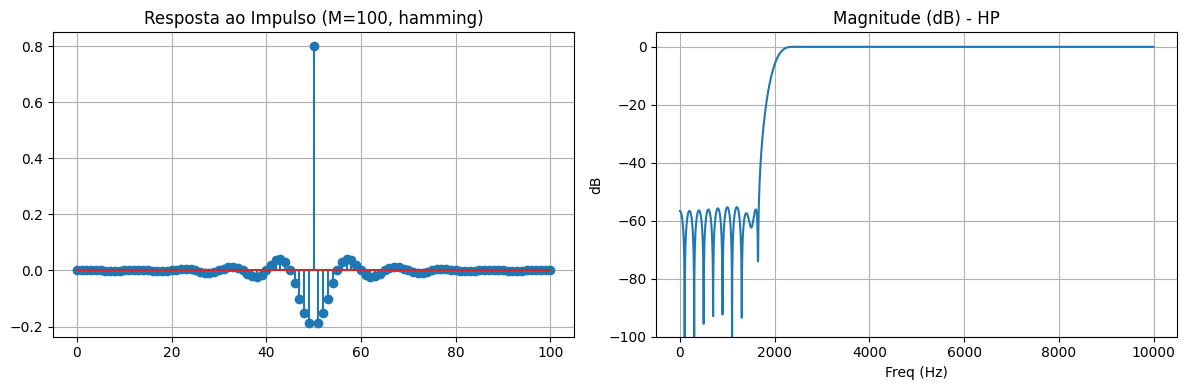

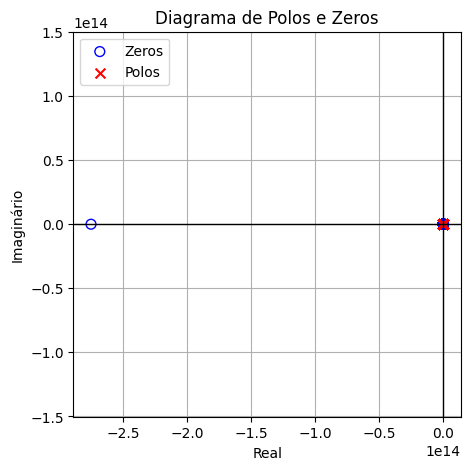


--- Janela: HANN ---


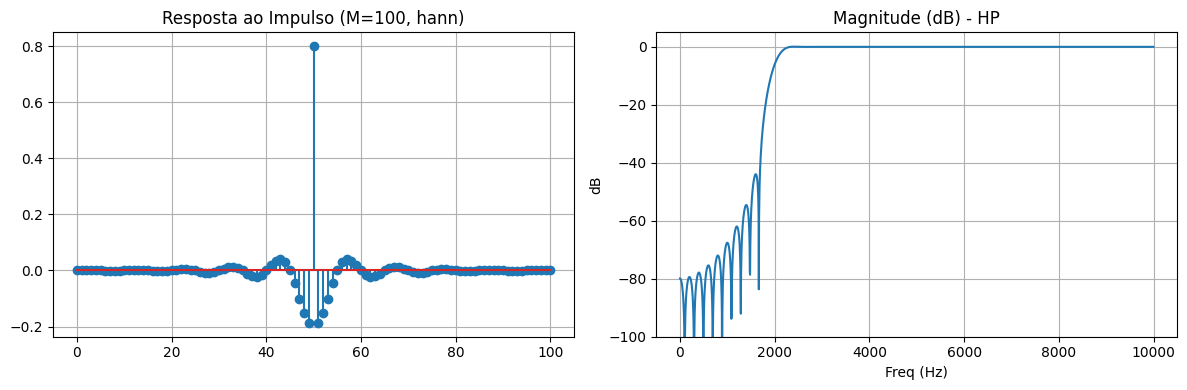

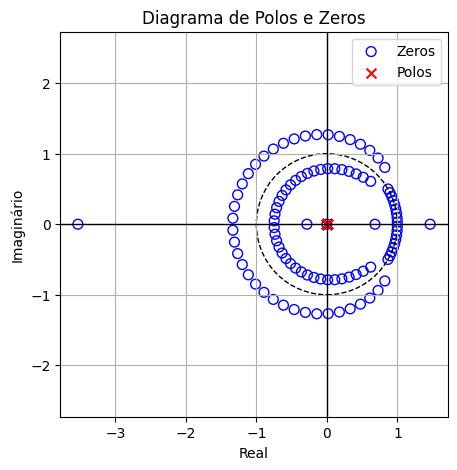


--- Janela: BLACKMAN ---


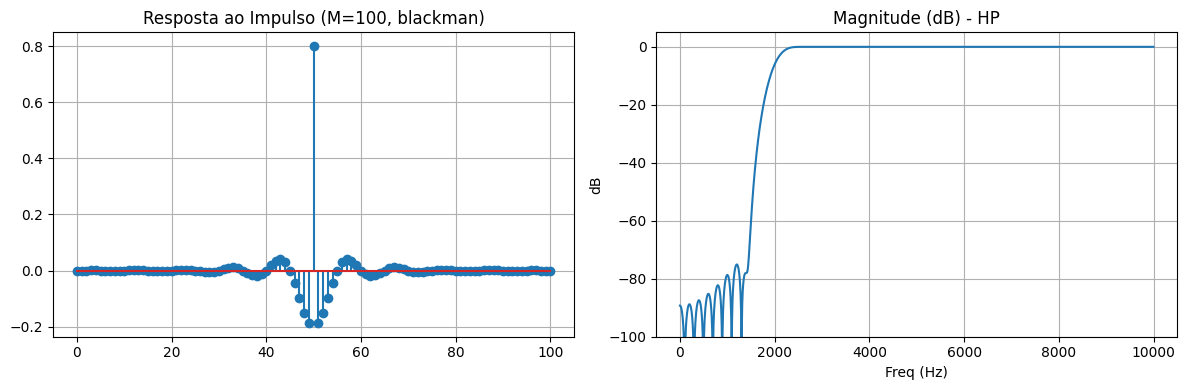

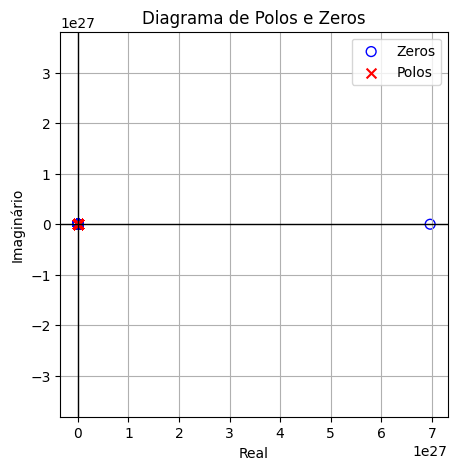

In [12]:
fs = 20000
fc = 2000

ordens = [20, 50, 100]
janelas = ['retangular', 'triangular', 'bartlett', 'hamming', 'hann', 'blackman']

for m_val in ordens:
    print(f'\n' + '='*50)
    print(f'ANÁLISE PASSA-ALTAS: M = {m_val}')
    print('='*50)

    for win_name in janelas:
        print(f'\n--- Janela: {win_name.upper()} ---')

        # Projetando o filtro passa-altas
        # wc = 2*pi*fc/fs
        # h_hp = h_passa_tudo - h_passa_baixas_ideal
        wc = 2 * np.pi * fc / fs
        h_ideal = ideal_lp(np.pi, m_val) - ideal_lp(wc, m_val)

        win = get_window(win_name, m_val)
        h_final = h_ideal * win

        # Visualizações
        projetar_e_plotar(m_val, win_name, 'hp', fs=fs, f1=fc)
        plot_poles_zeros(h_final)

### Questão 1 - Item (c)
**Projeto de Filtro Passa-Faixa**
- $f_s = 20000$ Hz
- $f_{c1} = 500$ Hz, $f_{c2} = 2000$ Hz
- $M \in \{20, 50, 100\}$
- Janelas: Retangular, Triangular, Bartlett, Hamming, Hann, Blackman.


ANÁLISE PASSA-FAIXA: M = 20

--- Janela: RETANGULAR ---


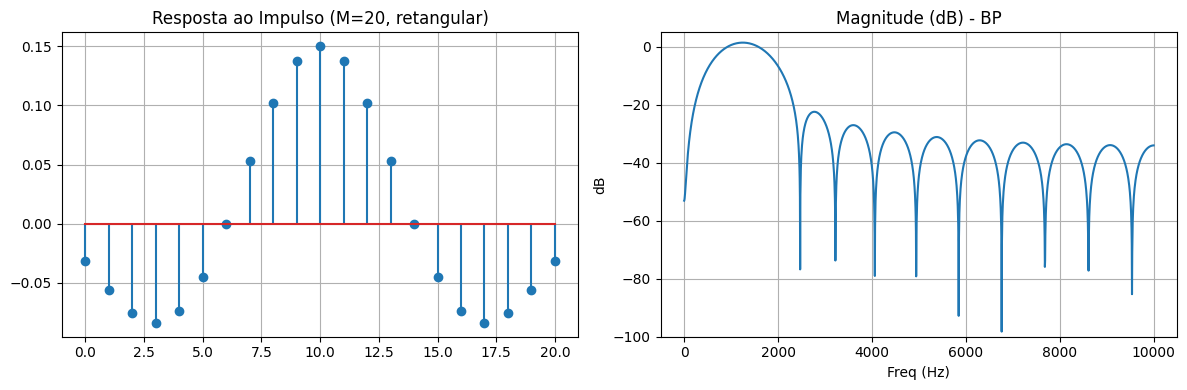

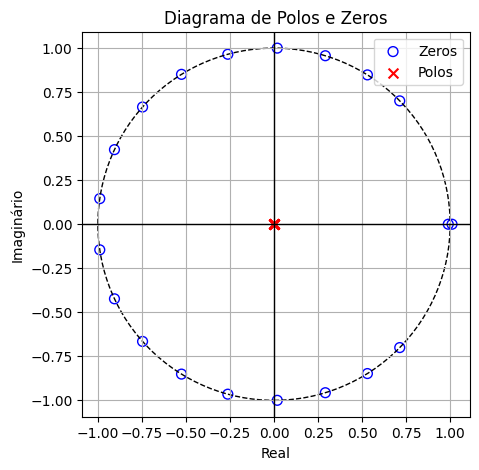


--- Janela: TRIANGULAR ---


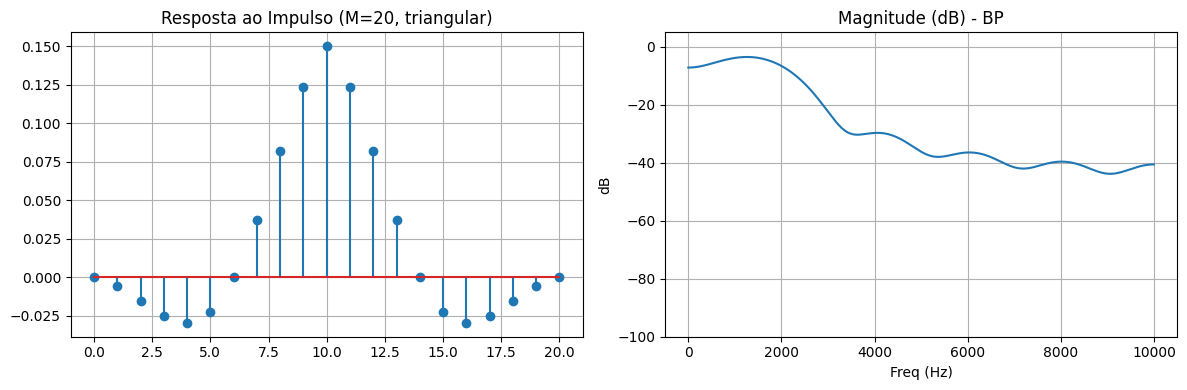

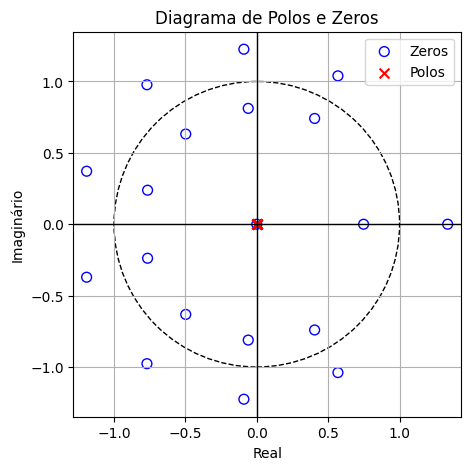


--- Janela: BARTLETT ---


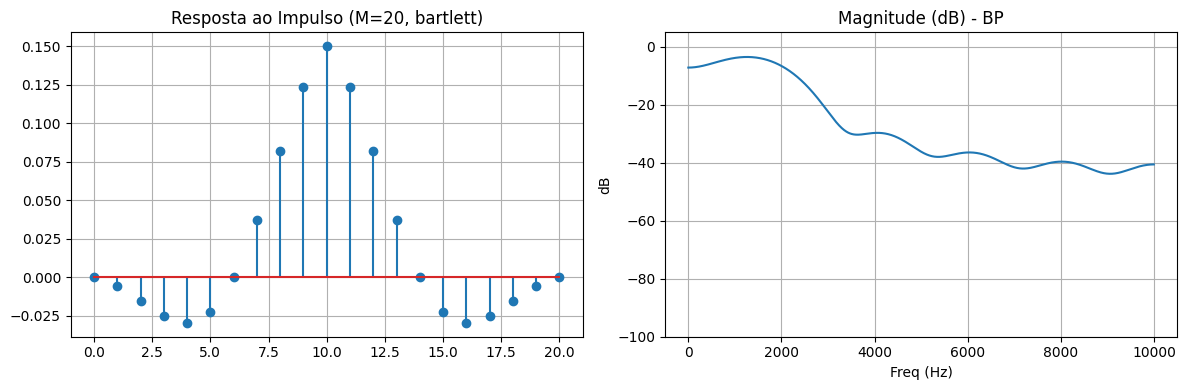

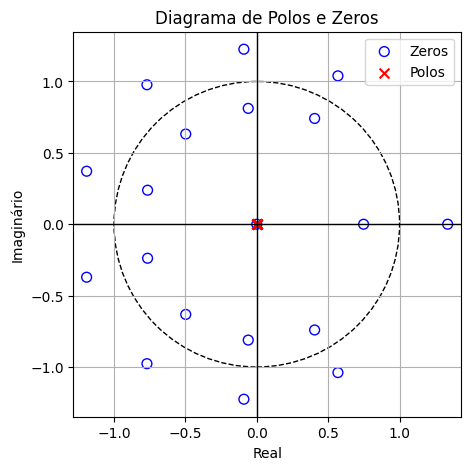


--- Janela: HAMMING ---


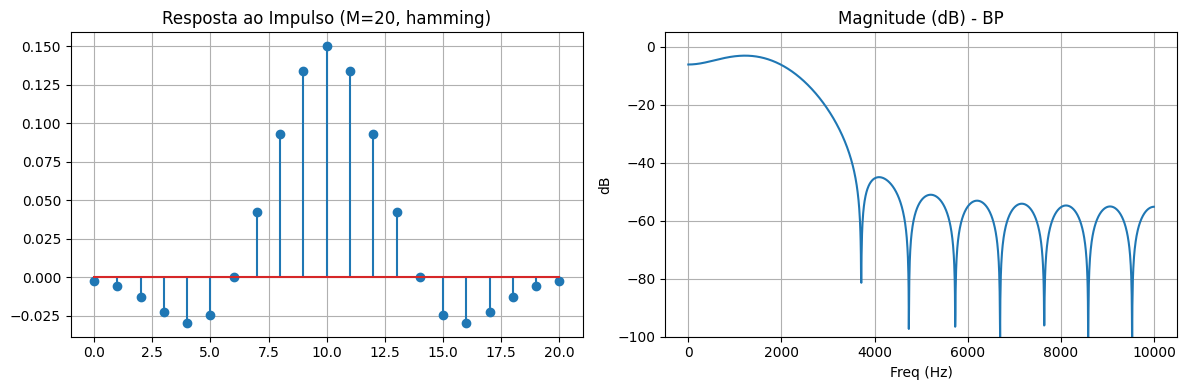

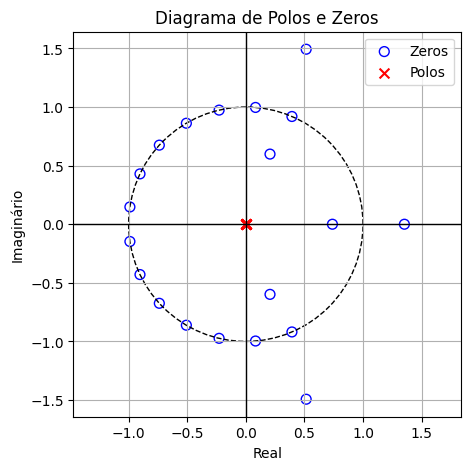


--- Janela: HANN ---


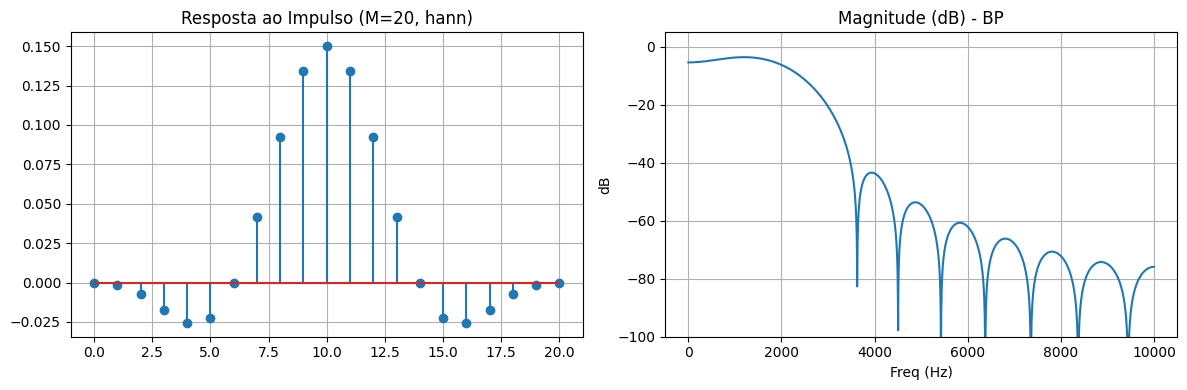

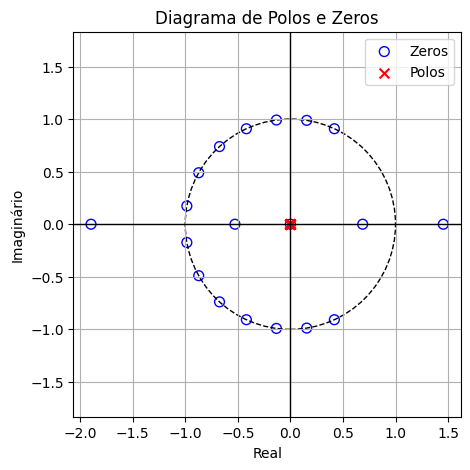


--- Janela: BLACKMAN ---


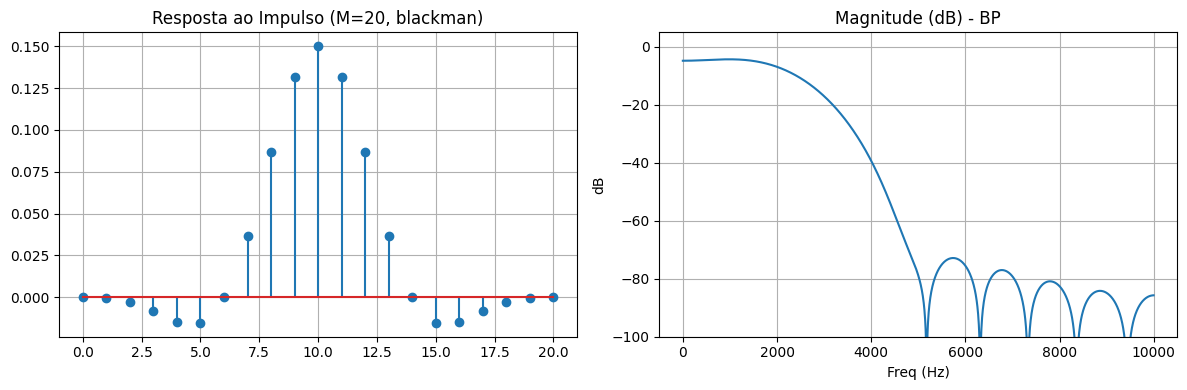

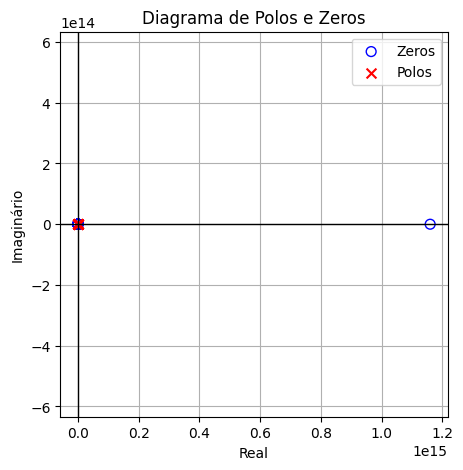


ANÁLISE PASSA-FAIXA: M = 50

--- Janela: RETANGULAR ---


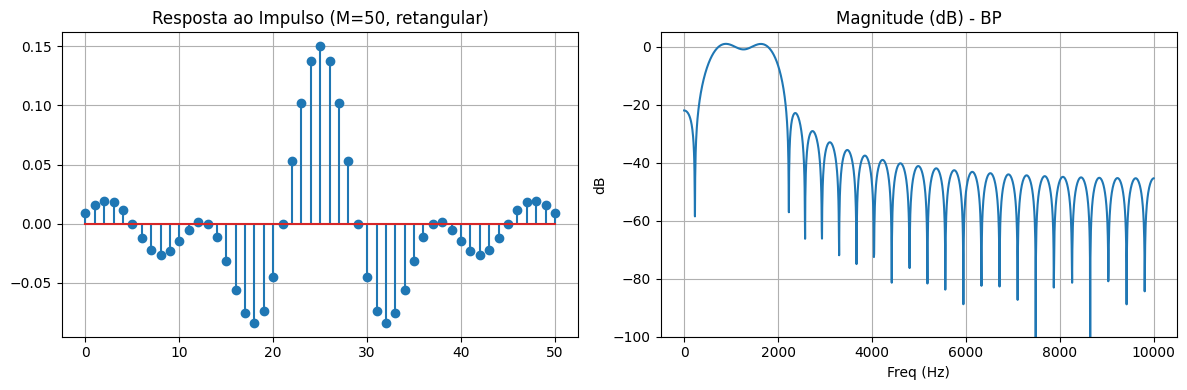

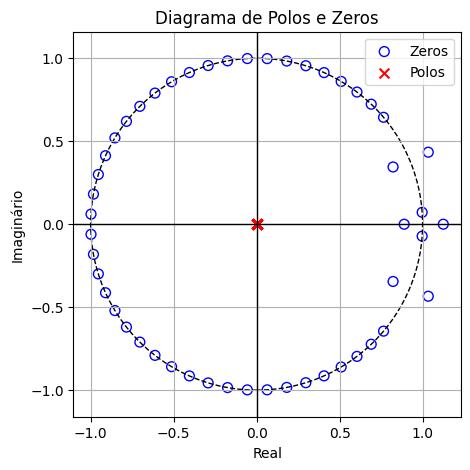


--- Janela: TRIANGULAR ---


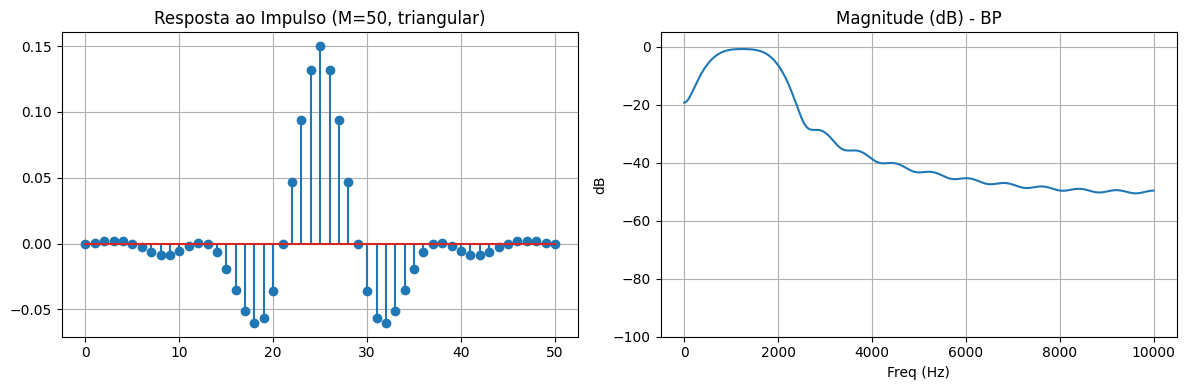

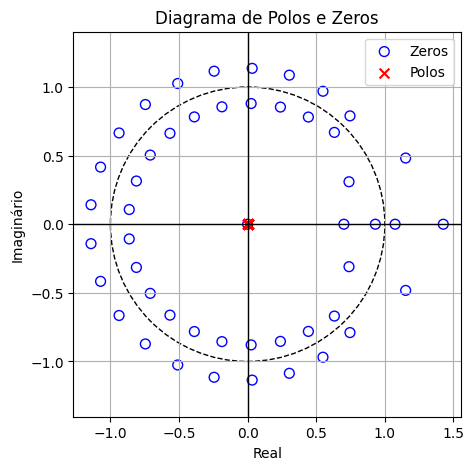


--- Janela: BARTLETT ---


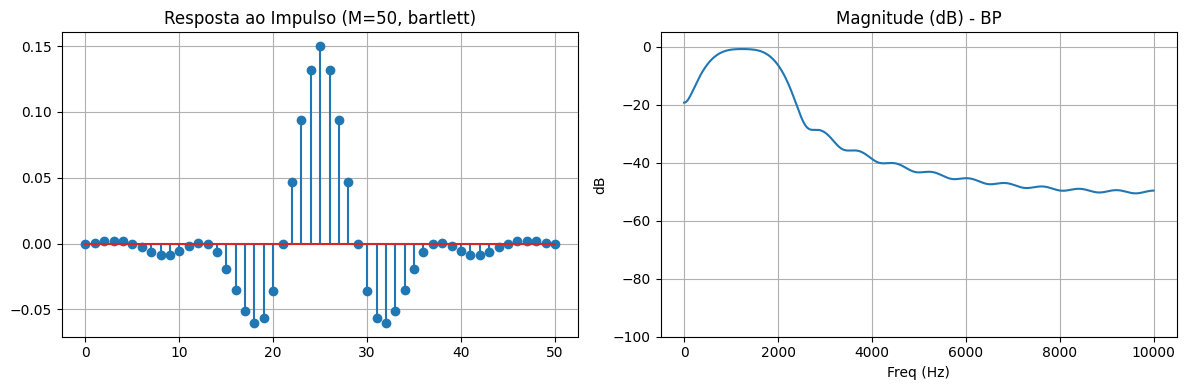

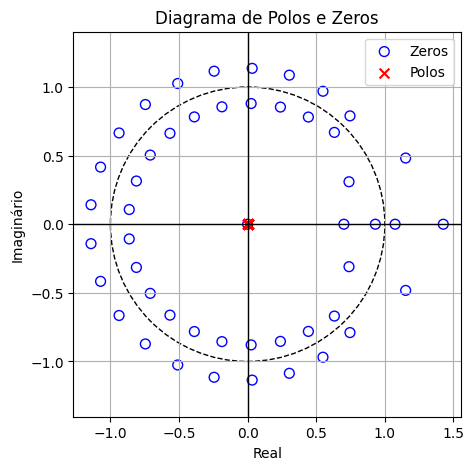


--- Janela: HAMMING ---


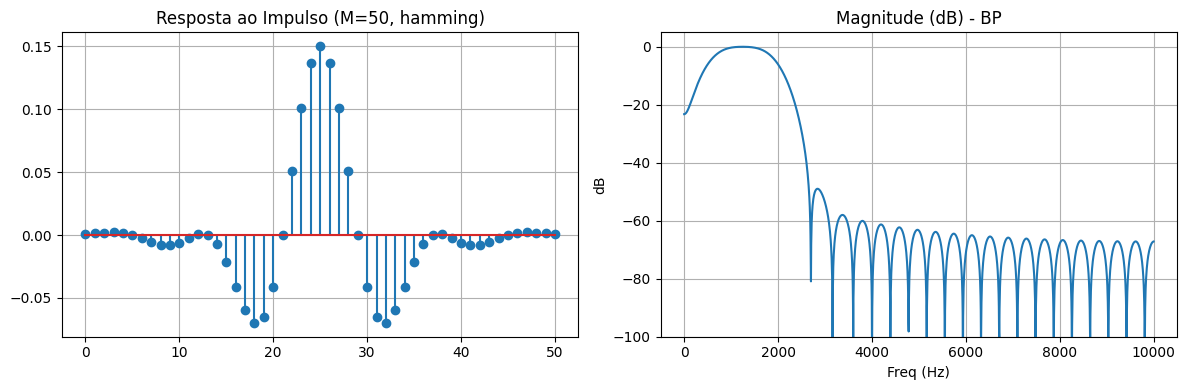

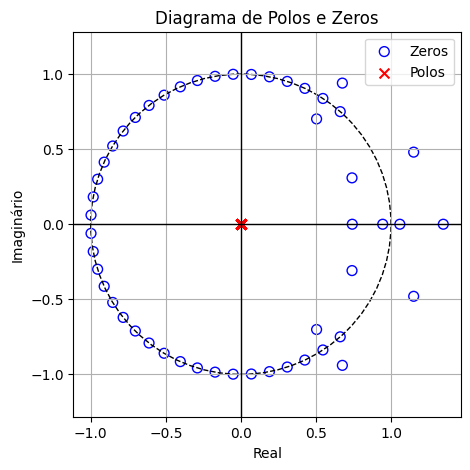


--- Janela: HANN ---


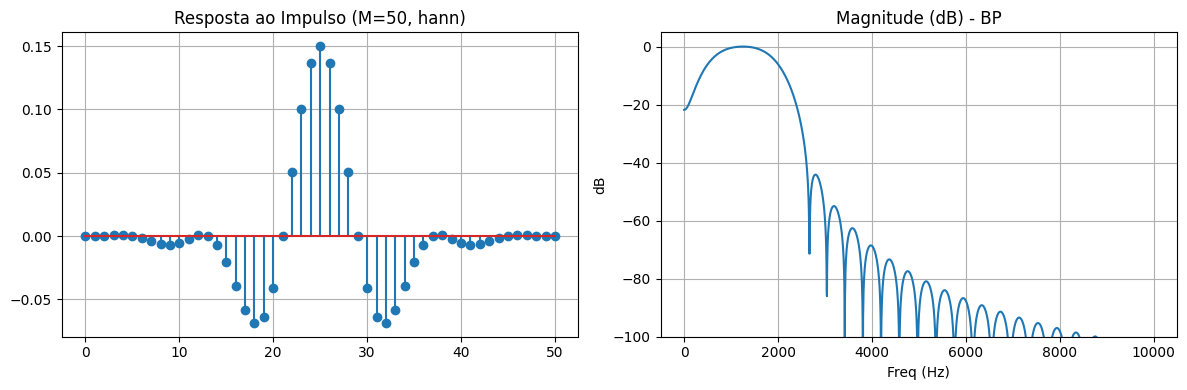

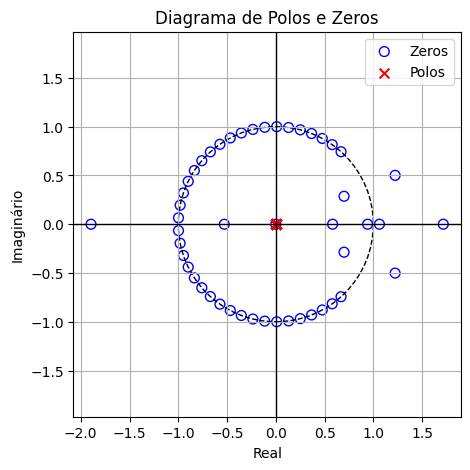


--- Janela: BLACKMAN ---


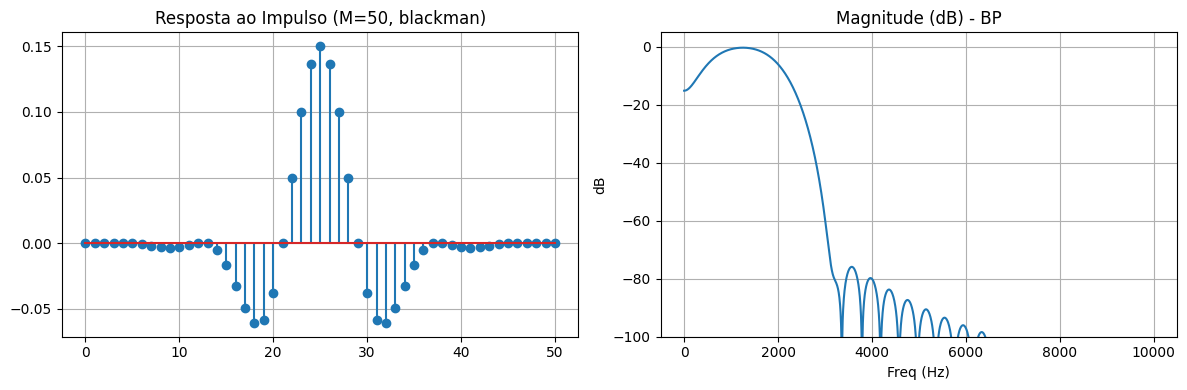

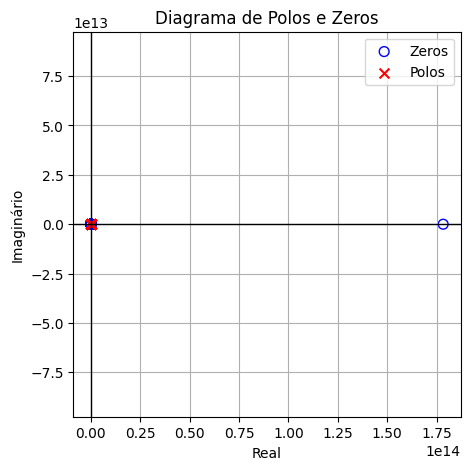


ANÁLISE PASSA-FAIXA: M = 100

--- Janela: RETANGULAR ---


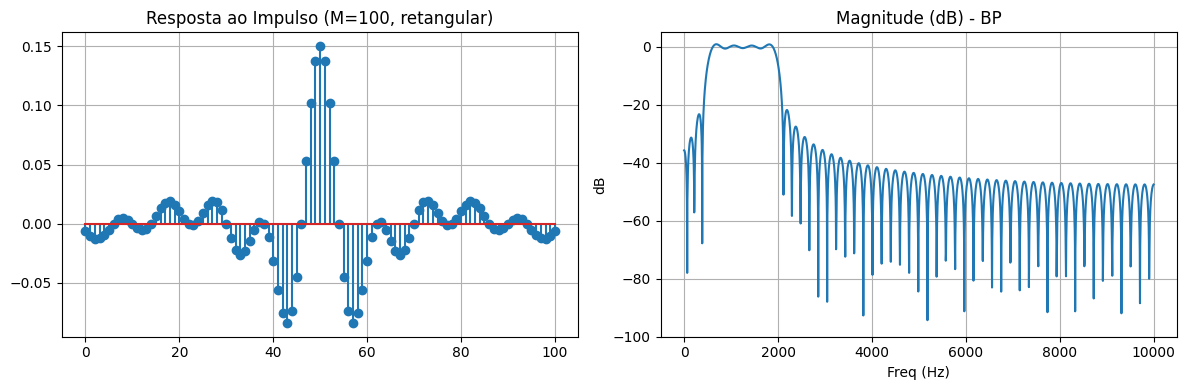

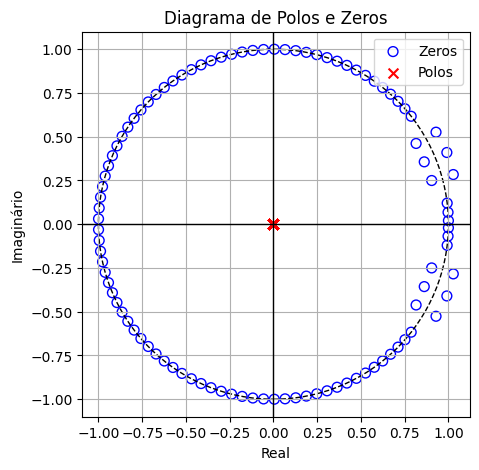


--- Janela: TRIANGULAR ---


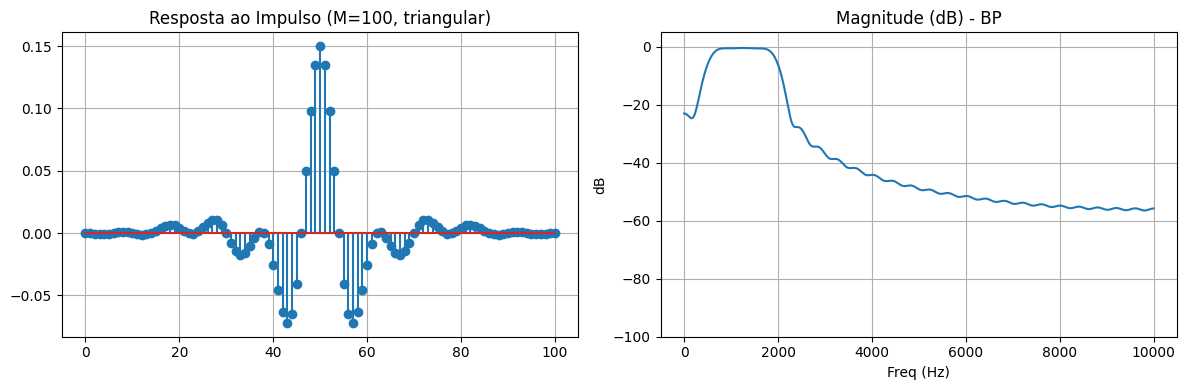

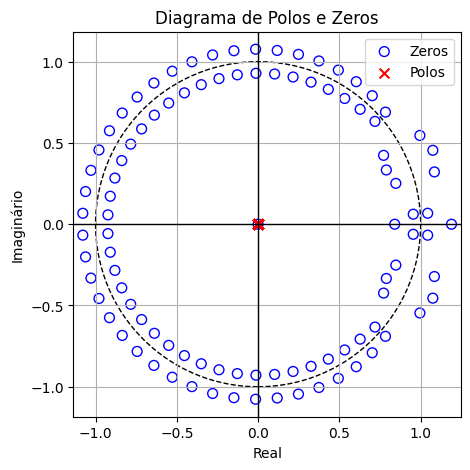


--- Janela: BARTLETT ---


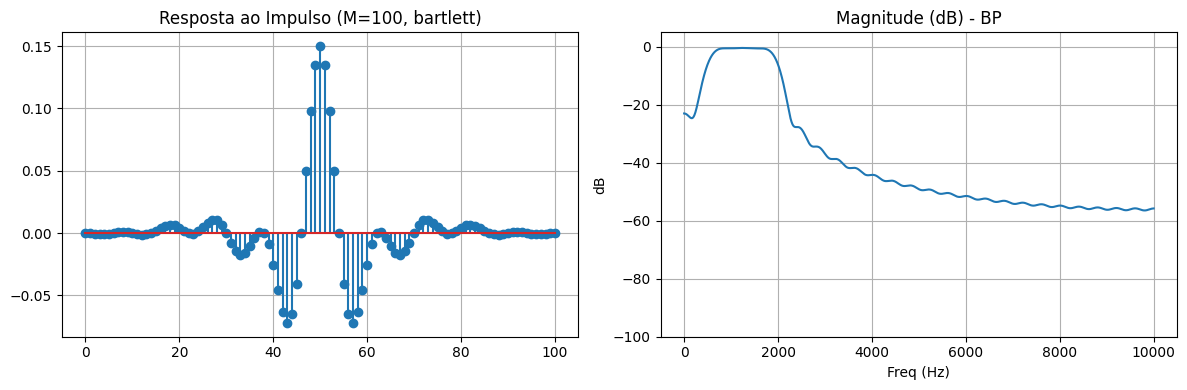

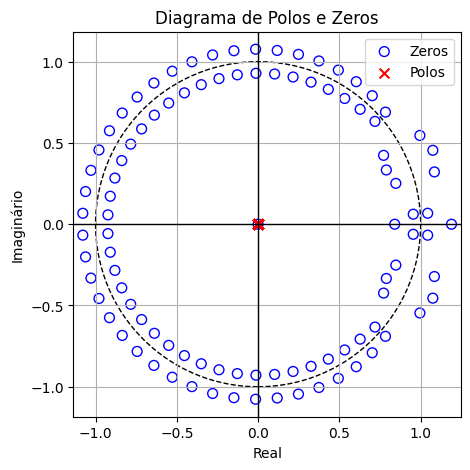


--- Janela: HAMMING ---


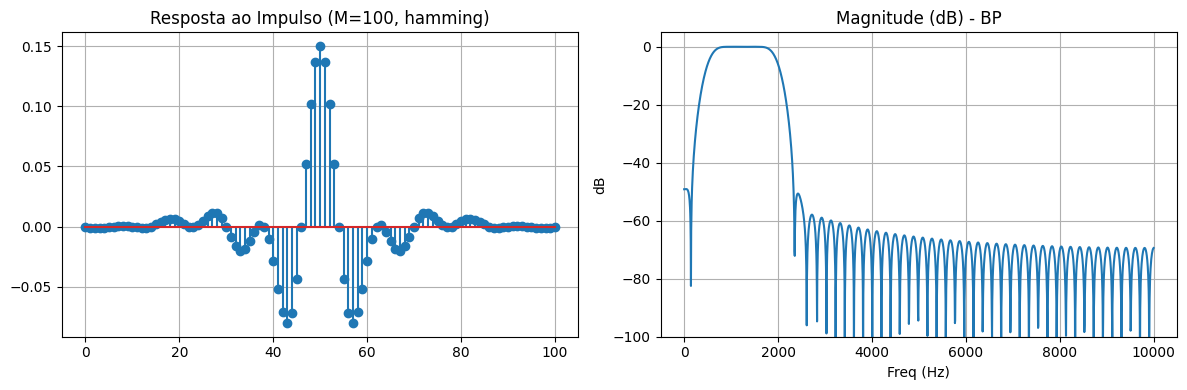

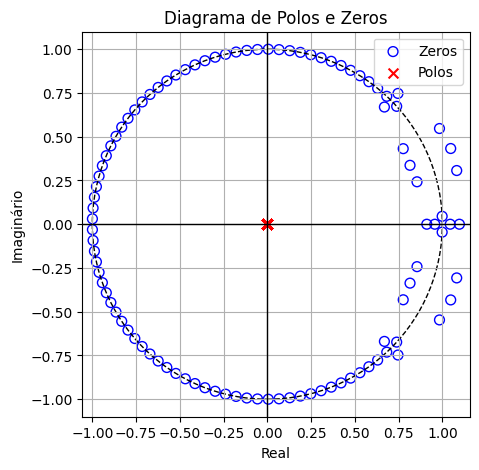


--- Janela: HANN ---


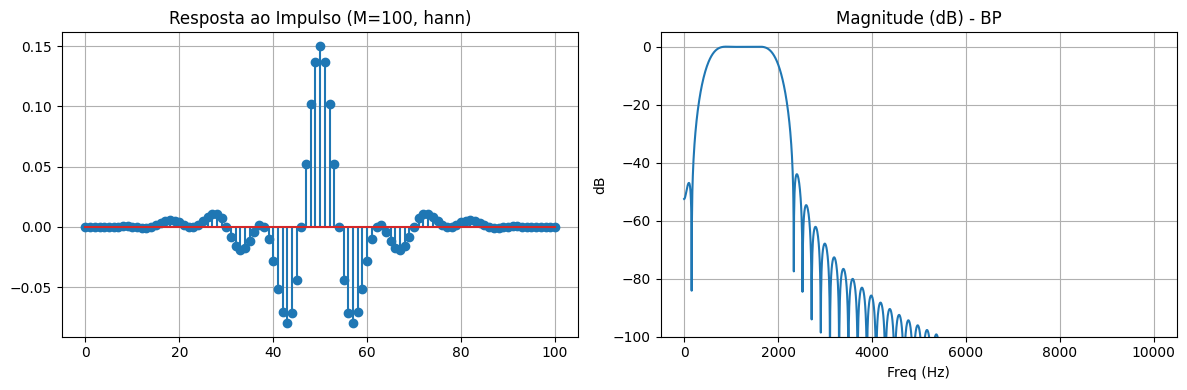

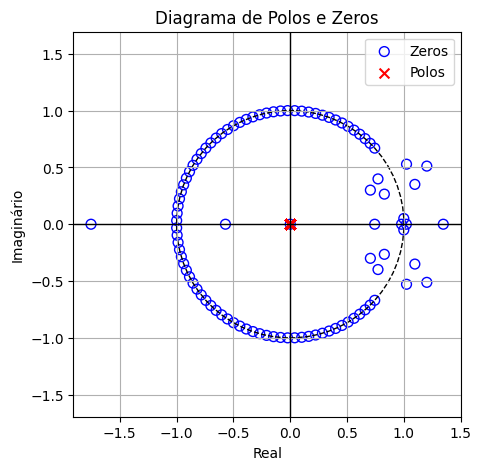


--- Janela: BLACKMAN ---


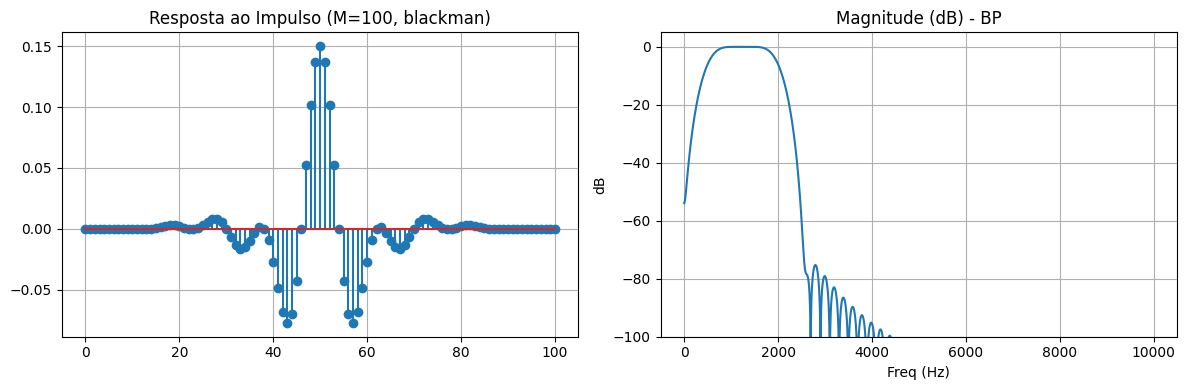

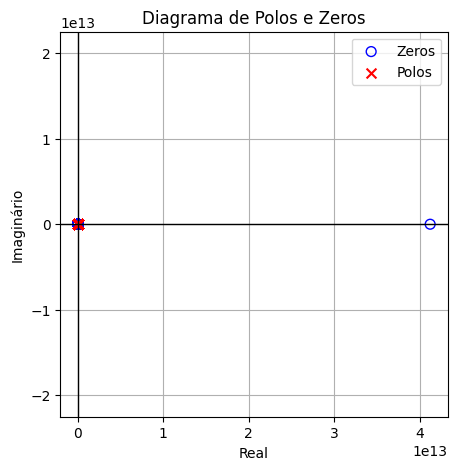

In [13]:
fs = 20000
fc1 = 500
fc2 = 2000

ordens = [20, 50, 100]
janelas = ['retangular', 'triangular', 'bartlett', 'hamming', 'hann', 'blackman']

for m_val in ordens:
    print(f'\n' + '='*50)
    print(f'ANÁLISE PASSA-FAIXA: M = {m_val}')
    print('='*50)

    for win_name in janelas:
        print(f'\n--- Janela: {win_name.upper()} ---')

        # Projetando o filtro passa-faixa
        # h_bp = h_lp(wc2) - h_lp(wc1)
        wc1 = 2 * np.pi * fc1 / fs
        wc2 = 2 * np.pi * fc2 / fs
        h_ideal = ideal_lp(wc2, m_val) - ideal_lp(wc1, m_val)

        win = get_window(win_name, m_val)
        h_final = h_ideal * win

        # Visualizações
        projetar_e_plotar(m_val, win_name, 'bp', fs=fs, f1=fc1, f2=fc2)
        plot_poles_zeros(h_final)

### Questão 1 - Item (d)
**Projeto de Filtro Rejeita-Faixa**
- $f_s = 20000$ Hz
- $f_{c1} = 1000$ Hz, $f_{c2} = 2500$ Hz
- $M \in \{20, 50, 100\}$
- Janelas: Retangular, Triangular, Bartlett, Hamming, Hann, Blackman.


ANÁLISE REJEITA-FAIXA: M = 20

--- Janela: RETANGULAR ---


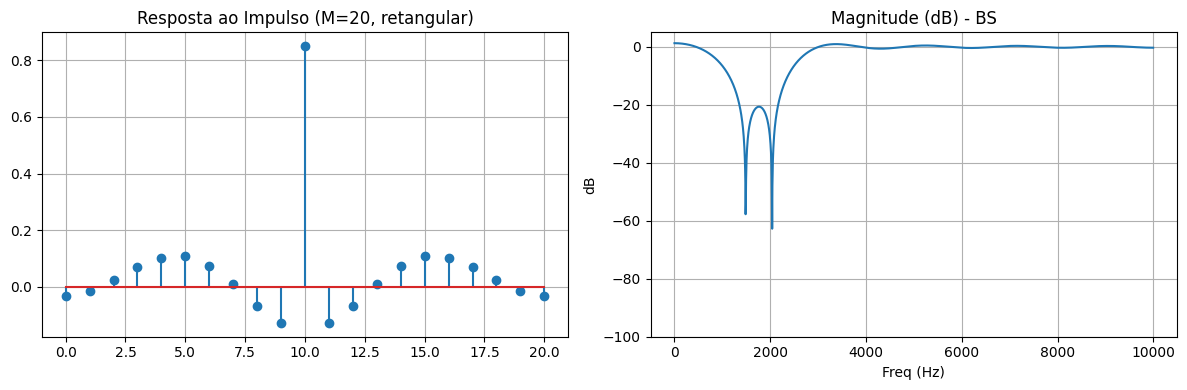

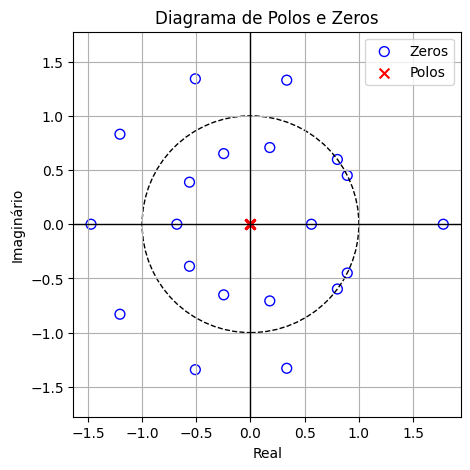


--- Janela: TRIANGULAR ---


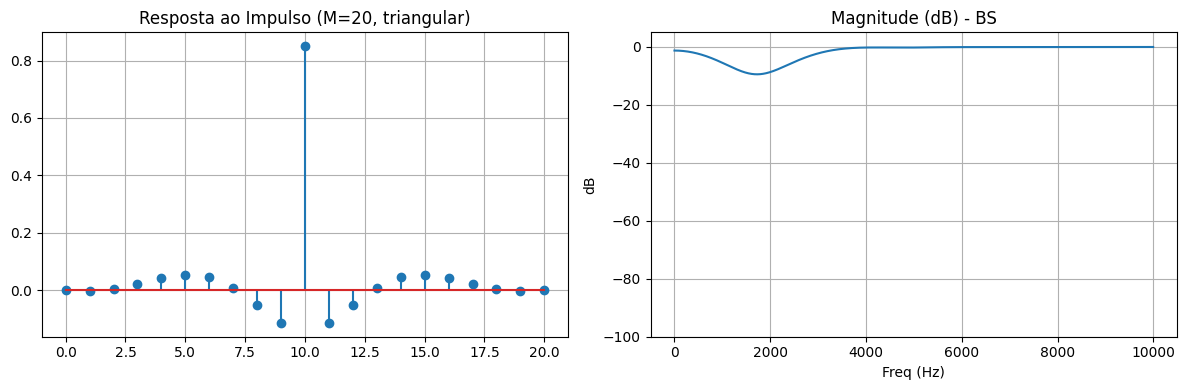

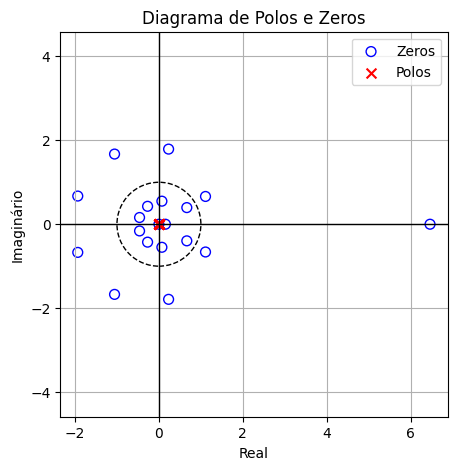


--- Janela: BARTLETT ---


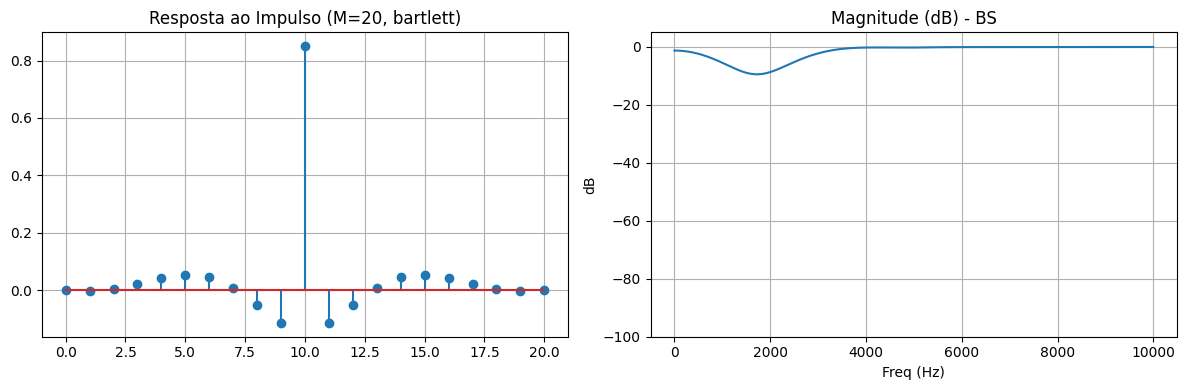

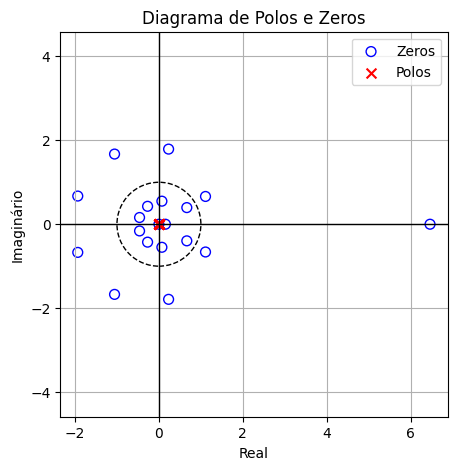


--- Janela: HAMMING ---


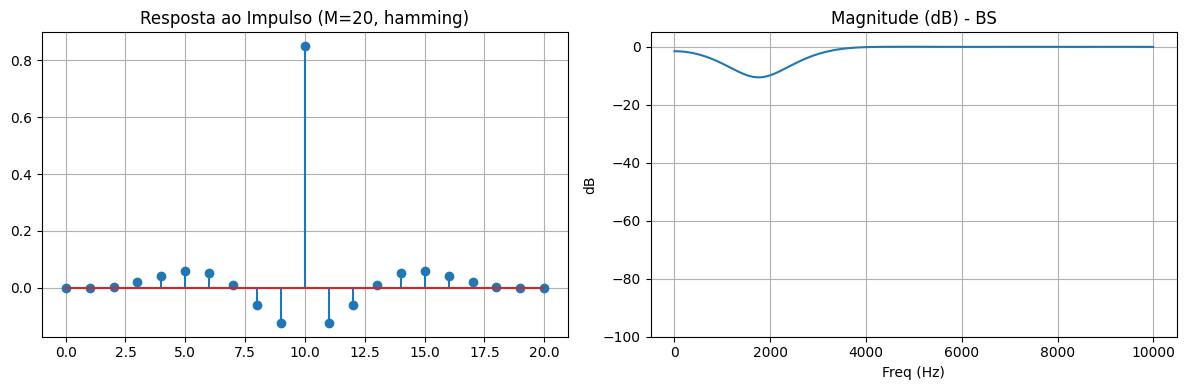

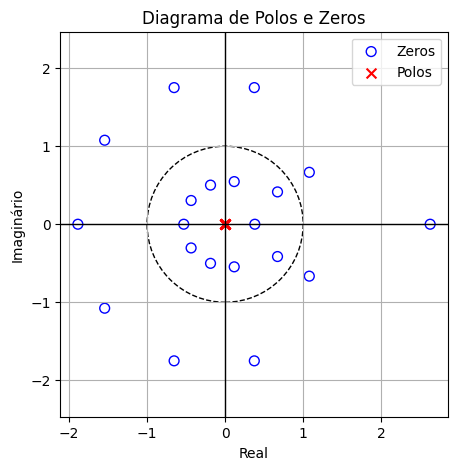


--- Janela: HANN ---


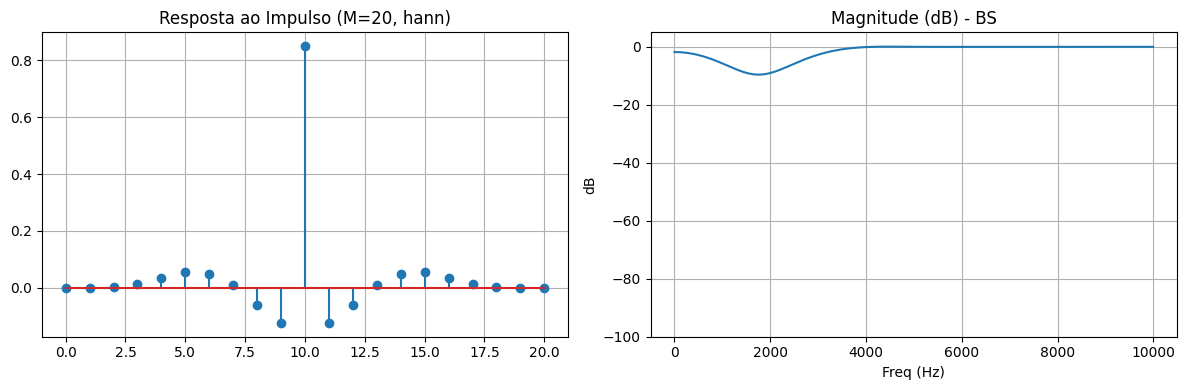

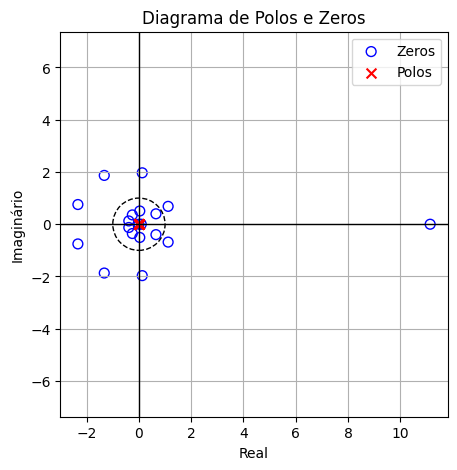


--- Janela: BLACKMAN ---


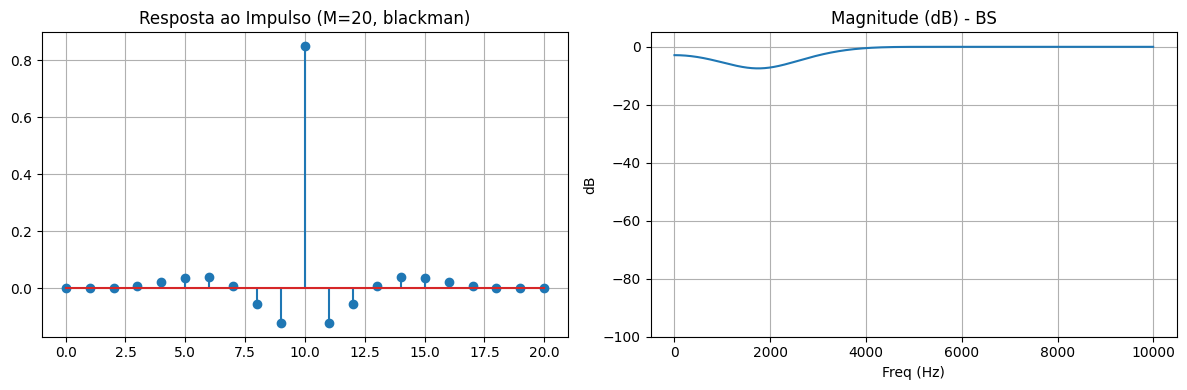

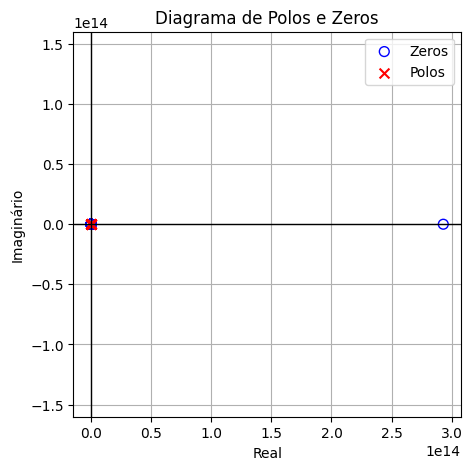


ANÁLISE REJEITA-FAIXA: M = 50

--- Janela: RETANGULAR ---


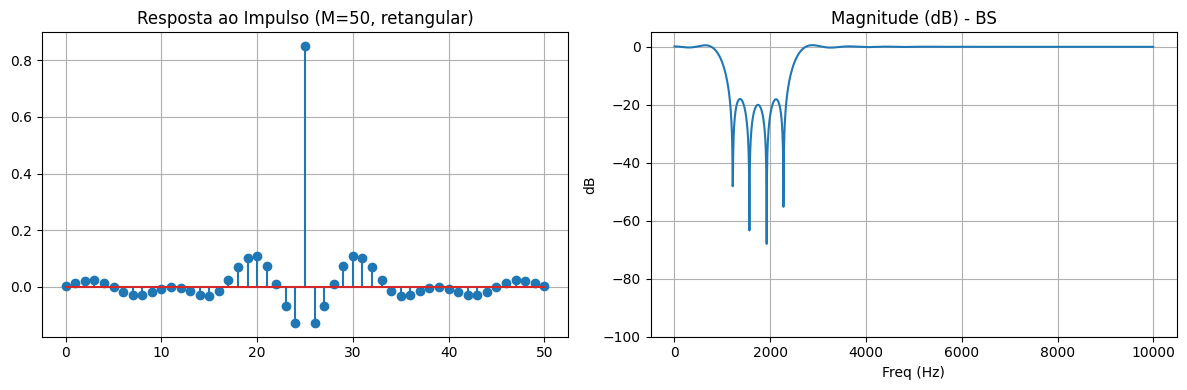

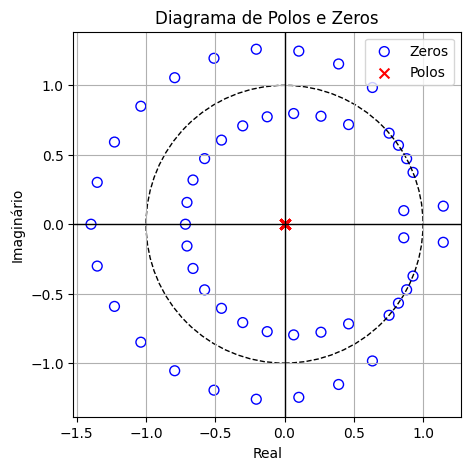


--- Janela: TRIANGULAR ---


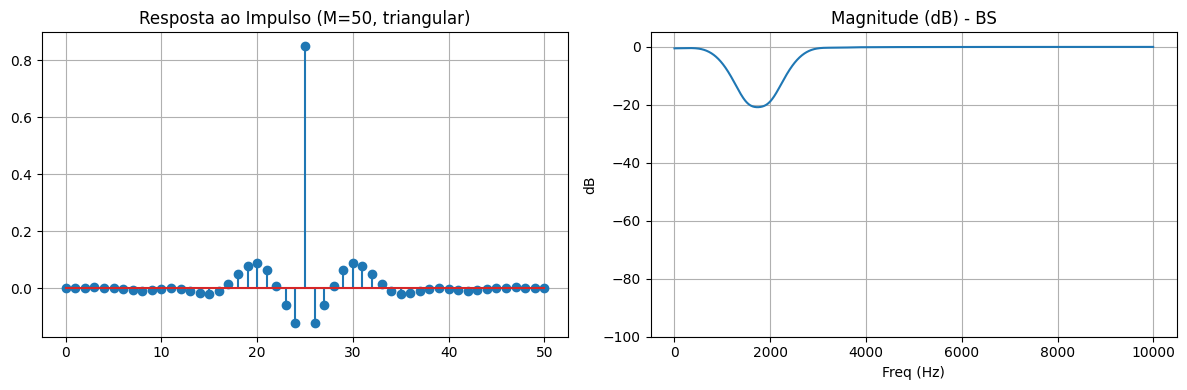

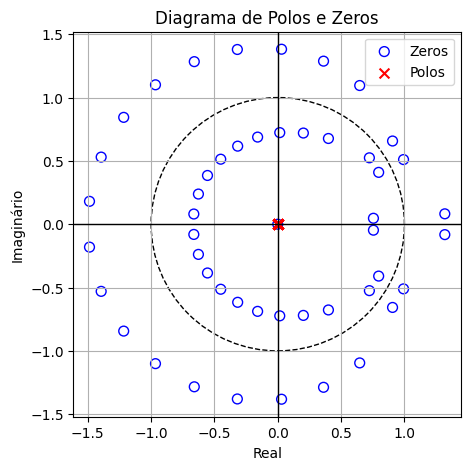


--- Janela: BARTLETT ---


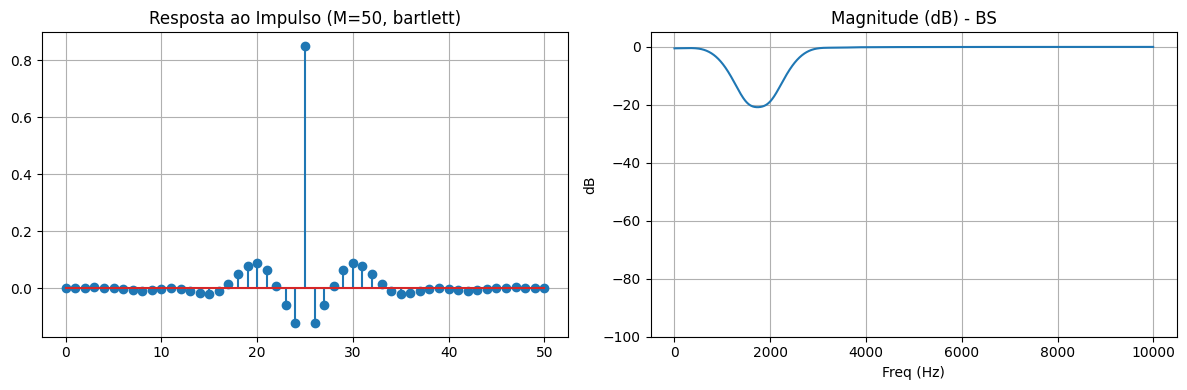

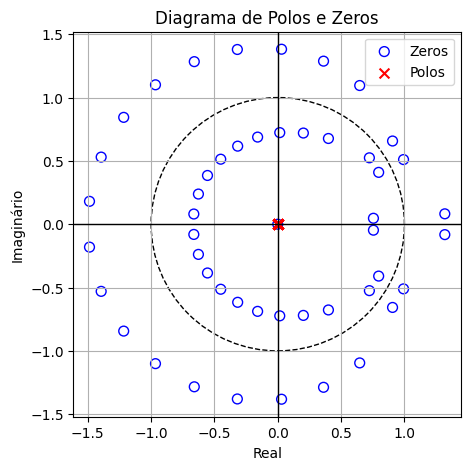


--- Janela: HAMMING ---


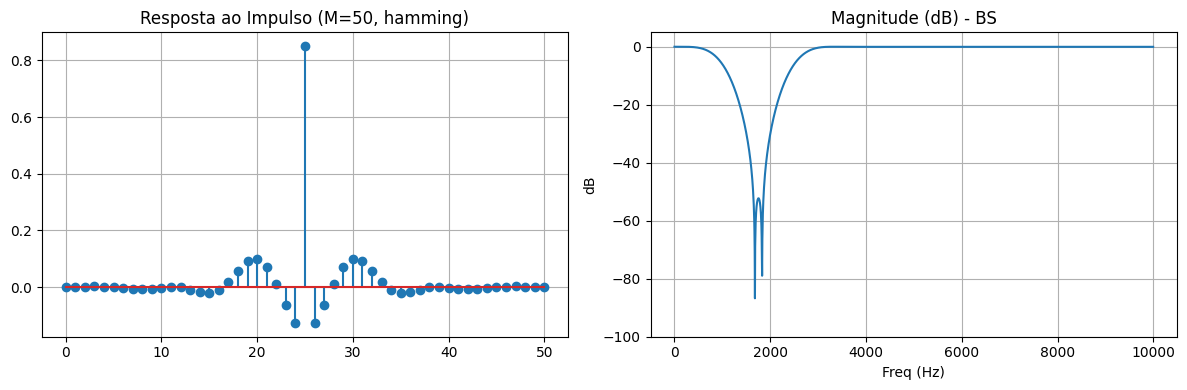

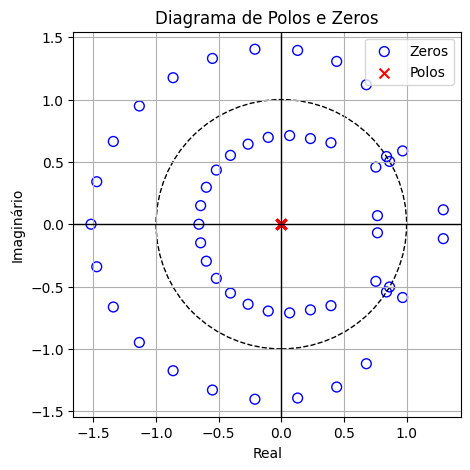


--- Janela: HANN ---


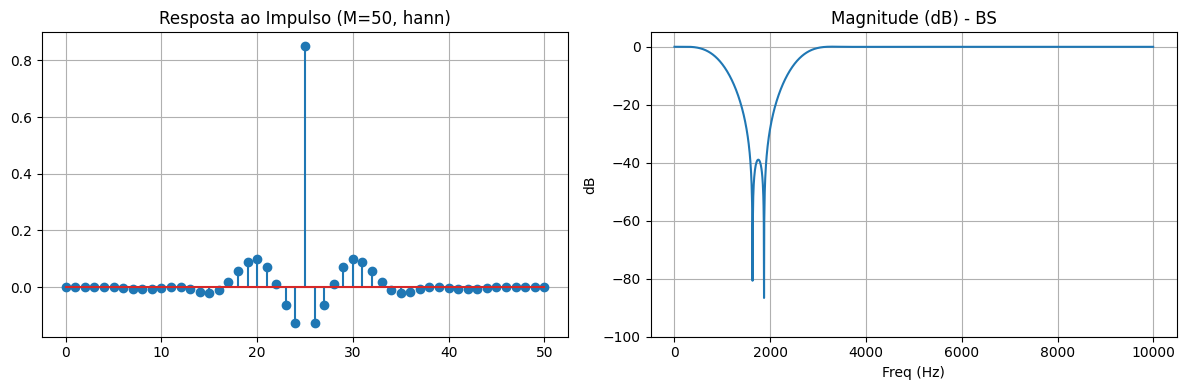

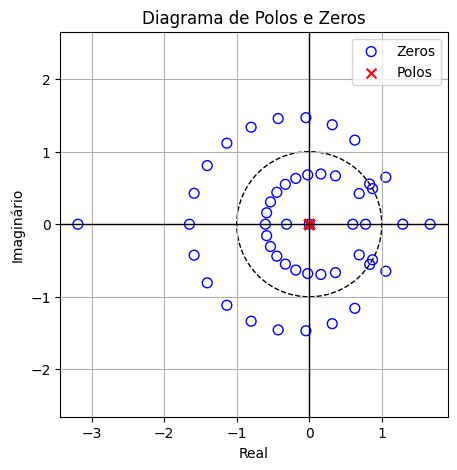


--- Janela: BLACKMAN ---


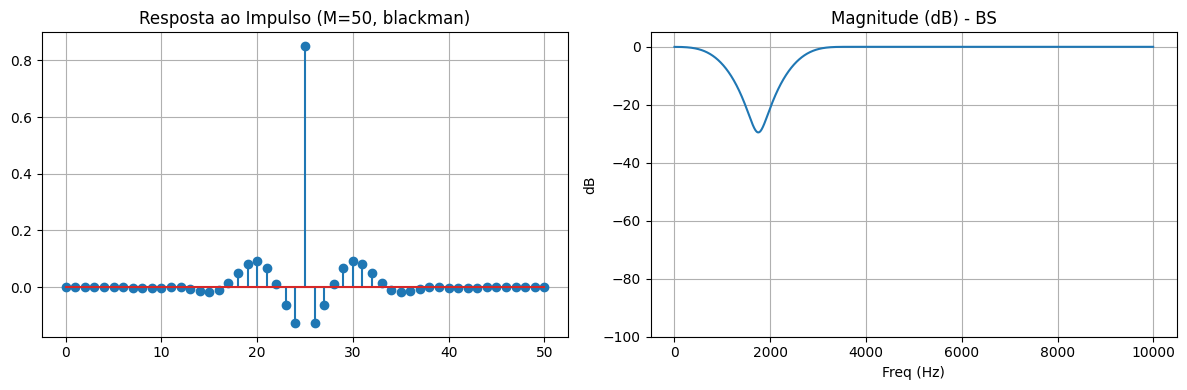

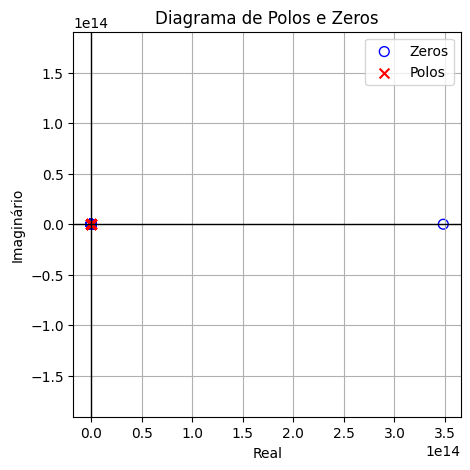


ANÁLISE REJEITA-FAIXA: M = 100

--- Janela: RETANGULAR ---


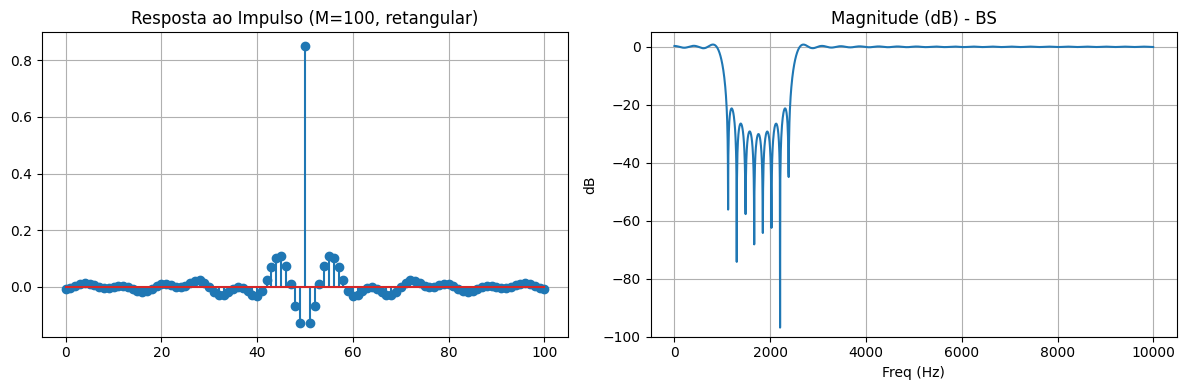

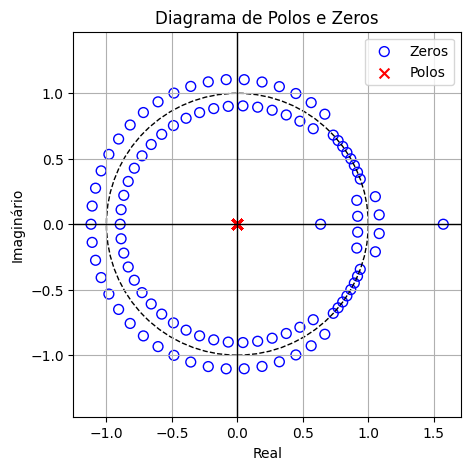


--- Janela: TRIANGULAR ---


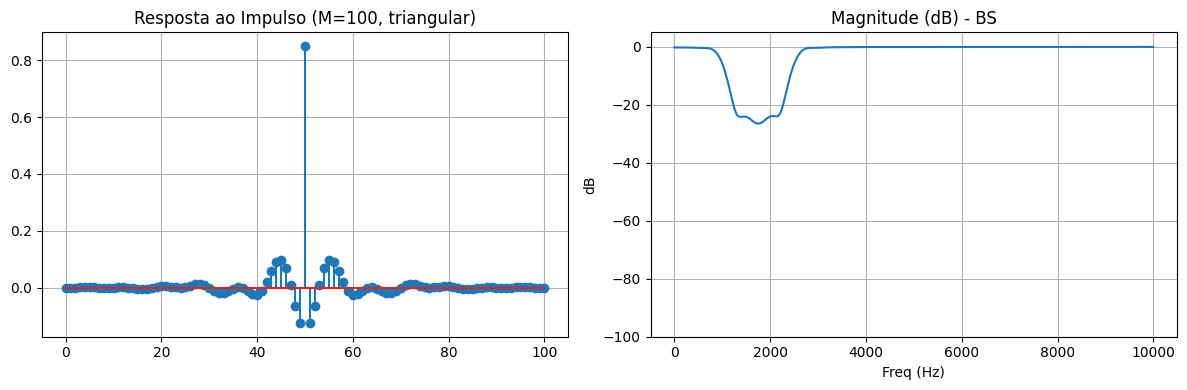

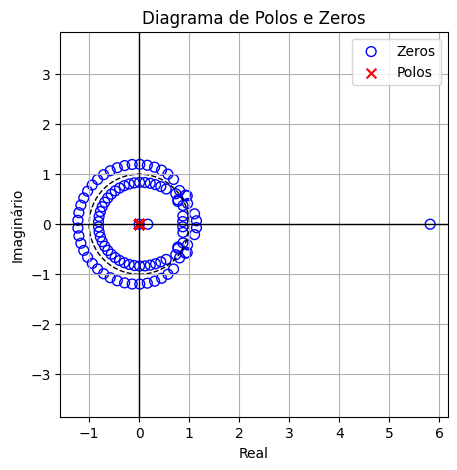


--- Janela: BARTLETT ---


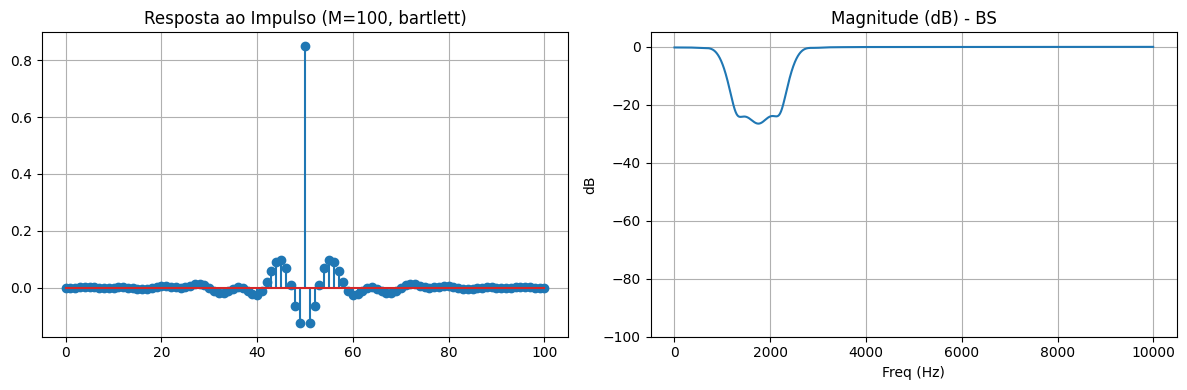

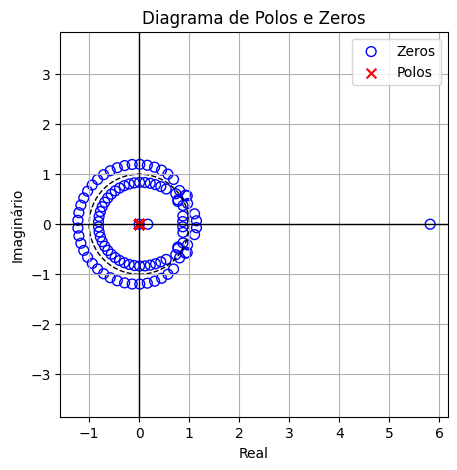


--- Janela: HAMMING ---


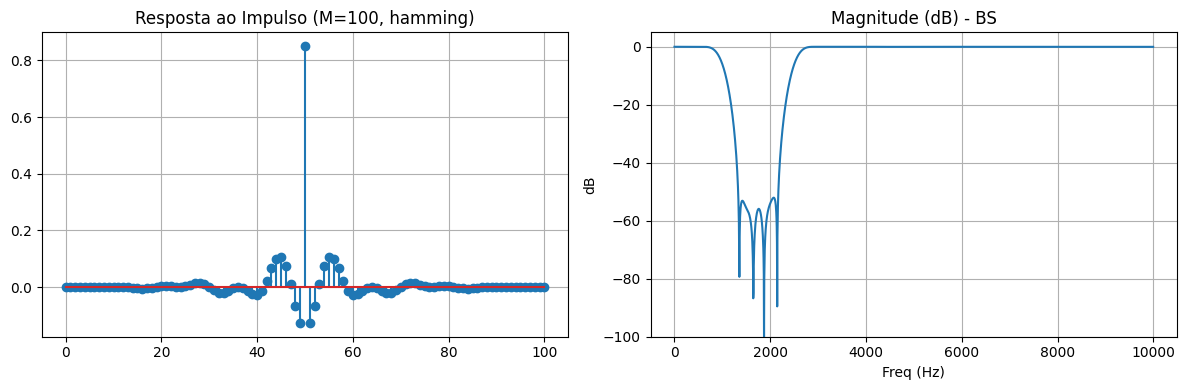

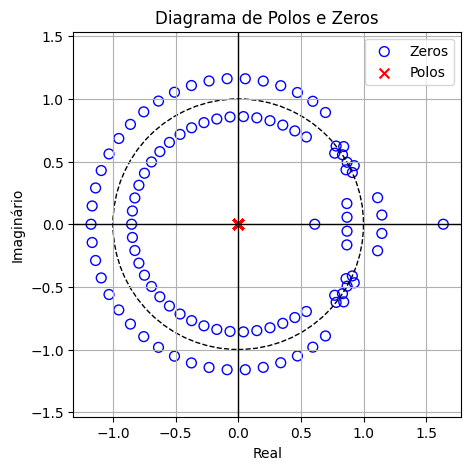


--- Janela: HANN ---


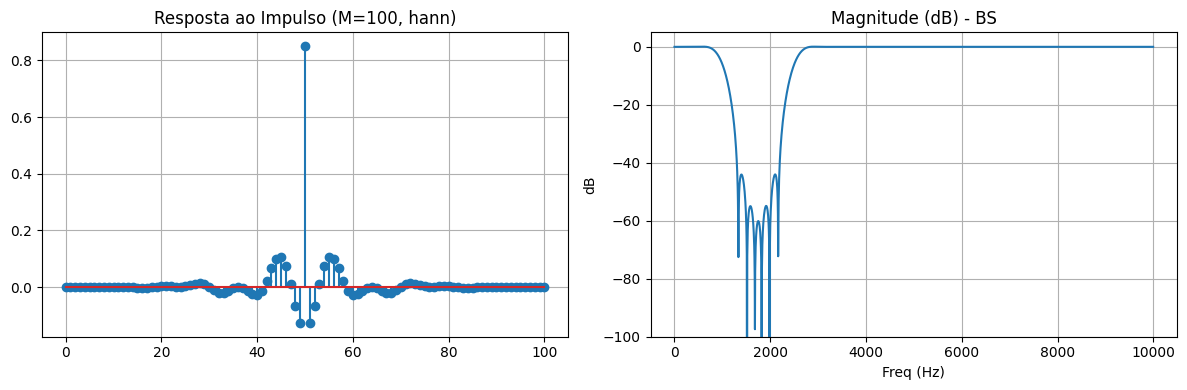

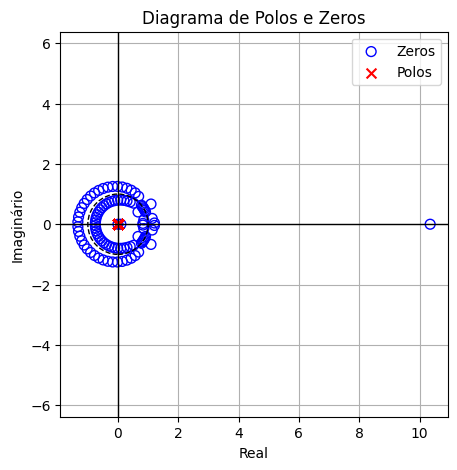


--- Janela: BLACKMAN ---


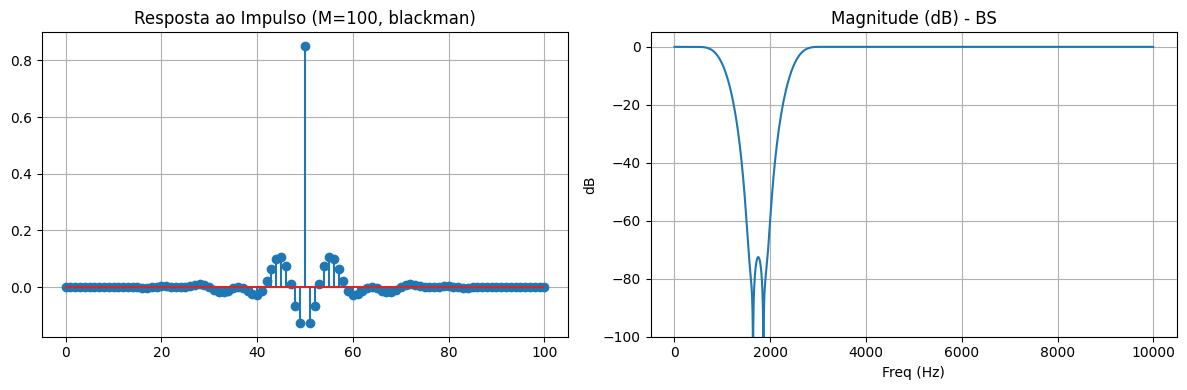

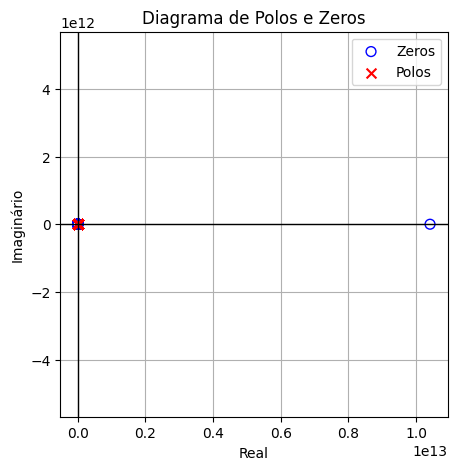

In [14]:
fs = 20000
fc1 = 1000
fc2 = 2500

ordens = [20, 50, 100]
janelas = ['retangular', 'triangular', 'bartlett', 'hamming', 'hann', 'blackman']

for m_val in ordens:
    print(f'\n' + '='*50)
    print(f'ANÁLISE REJEITA-FAIXA: M = {m_val}')
    print('='*50)

    for win_name in janelas:
        print(f'\n--- Janela: {win_name.upper()} ---')

        # Projetando o filtro rejeita-faixa
        # h_bs = h_lp(wc1) + (h_passa_tudo - h_lp(wc2))
        wc1 = 2 * np.pi * fc1 / fs
        wc2 = 2 * np.pi * fc2 / fs
        h_ideal = ideal_lp(wc1, m_val) + (ideal_lp(np.pi, m_val) - ideal_lp(wc2, m_val))

        win = get_window(win_name, m_val)
        h_final = h_ideal * win

        # Visualizações
        projetar_e_plotar(m_val, win_name, 'bs', fs=fs, f1=fc1, f2=fc2)
        plot_poles_zeros(h_final)